In [2]:
# Chargement des librairies
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import plotly.express as px
import missingno as msn
import IPython as ip
from IPython.display import display
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import statsmodels as stat
from statsmodels.tsa.api import Holt
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from math import pi
from mpl_toolkits.axes_grid1 import make_axes_locatable
warnings.simplefilter('ignore', ConvergenceWarning)
%matplotlib inline

# Importation et Analyse préliminaire des Datasets

# EdStatsCountry

In [103]:
dataCountry = pd.read_csv('EdStatsCountry.csv')
dataCountry.head(3)

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,Unnamed: 31
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,SNA data for 2000-2011 are updated from offici...,Latin America & Caribbean,High income: nonOECD,AW,...,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN,NaN
1,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,...,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.0,2000,NaN
2,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,"April 2013 database update: Based on IMF data,...",Sub-Saharan Africa,Upper middle income,AO,...,General Data Dissemination System (GDDS),1970,"Malaria Indicator Survey (MIS), 2011","Integrated household survey (IHS), 2008",NaN,2015,NaN,NaN,2005,NaN


In [104]:
nRow, nCol = dataCountry.shape
print(f'Le jeu de données contient {nRow} lignes et {nCol} colonnes.')

Le jeu de données contient 241 lignes et 32 colonnes.


In [105]:
# Résumé des variables quantitatives
dataCountry.describe()


,National accounts reference year,Latest industrial data,Latest trade data,Unnamed: 31
count,32.00000,107.000000,185.000000,0.0
mean,2001.53125,2008.102804,2010.994595,NaN
std,5.24856,2.616834,2.569675,NaN
min,1987.00000,2000.000000,1995.000000,NaN
25%,1996.75000,2007.500000,2011.000000,NaN
50%,2002.00000,2009.000000,2012.000000,NaN
75%,2005.00000,2010.000000,2012.000000,NaN
max,2012.00000,2010.000000,2012.000000,NaN


On remarque la présence d'une colonne entièrement vide : Unnamed:31
On ne remarque pas la présence d'Outliers 

In [106]:
# Valeurs manquantes
nb_na1 = dataCountry.isnull().sum()
nb_na1[nb_na1>0]

2-alpha code                                           3
Currency Unit                                         26
Special Notes                                         96
Region                                                27
Income Group                                          27
WB-2 code                                              1
National accounts base year                           36
National accounts reference year                     209
SNA price valuation                                   44
Lending category                                      97
Other groups                                         183
System of National Accounts                           26
Alternative conversion factor                        194
PPP survey year                                       96
Balance of Payments Manual in use                     60
External debt Reporting status                       117
System of trade                                       41
Government Accounting concept  

<AxesSubplot:>

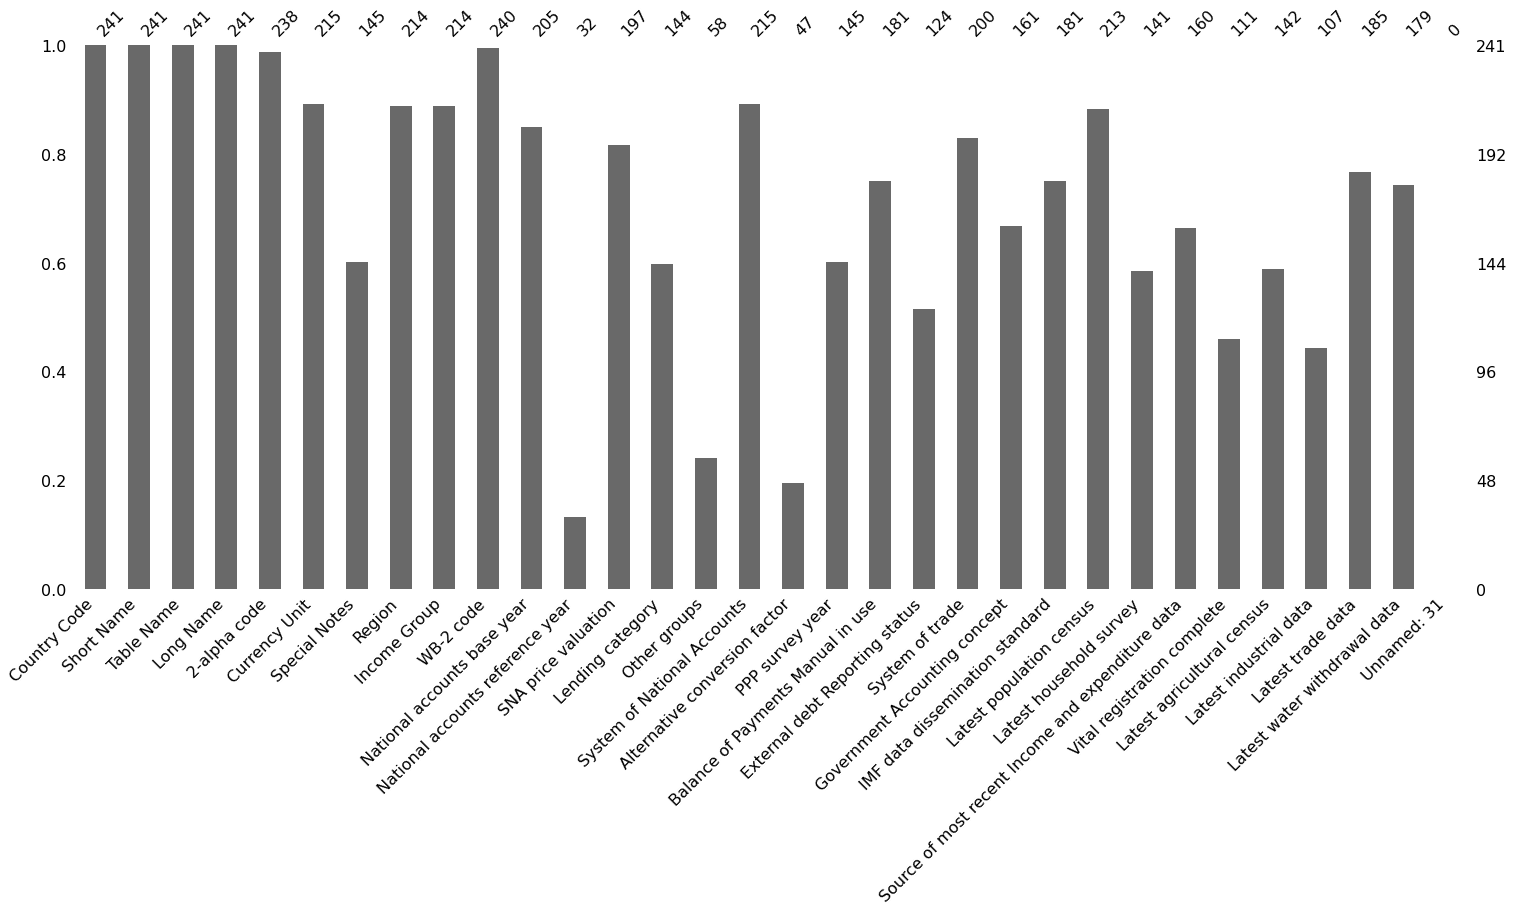

In [107]:
#graphe des missing values 
msn.bar(dataCountry)


In [9]:
# Doublons
doublons = dataCountry[dataCountry.duplicated(['Country Code'], keep=False)]
doublons = doublons.shape[0]
print(f'Nombre de doublons sur le code pays : {doublons}')

Nombre de doublons sur le code pays : 0


# EdStatsCountry-Series

In [108]:
# Chargement du jeu de données
dataseries = pd.read_csv('EdStatsCountry-Series.csv', delimiter=',')
dataseries.head(3)

,CountryCode,SeriesCode,DESCRIPTION,Unnamed: 3
0,ABW,SP.POP.TOTL,Data sources : United Nations World Population...,NaN
1,ABW,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
2,AFG,SP.POP.GROW,Data sources: United Nations World Population ...,NaN


In [109]:
# Taille :
nRow, nCol = dataseries.shape
print(f'Le jeu de données contient {nRow} lignes et {nCol} colonnes.')

Le jeu de données contient 613 lignes et 4 colonnes.


In [110]:
# Résumé des variables qualitatives
dataseries.describe(exclude=[np.number])


,CountryCode,SeriesCode,DESCRIPTION
count,613,613,613
unique,211,21,97
top,MDA,SP.POP.TOTL,Data sources : United Nations World Population...
freq,18,211,154


In [13]:
#Résumé des variables quantitatives
dataseries.describe()

,Unnamed: 3
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [111]:
# Valeurs manquantes
dataseries.isnull().sum()

CountryCode      0
SeriesCode       0
DESCRIPTION      0
Unnamed: 3     613
dtype: int64

<AxesSubplot:>

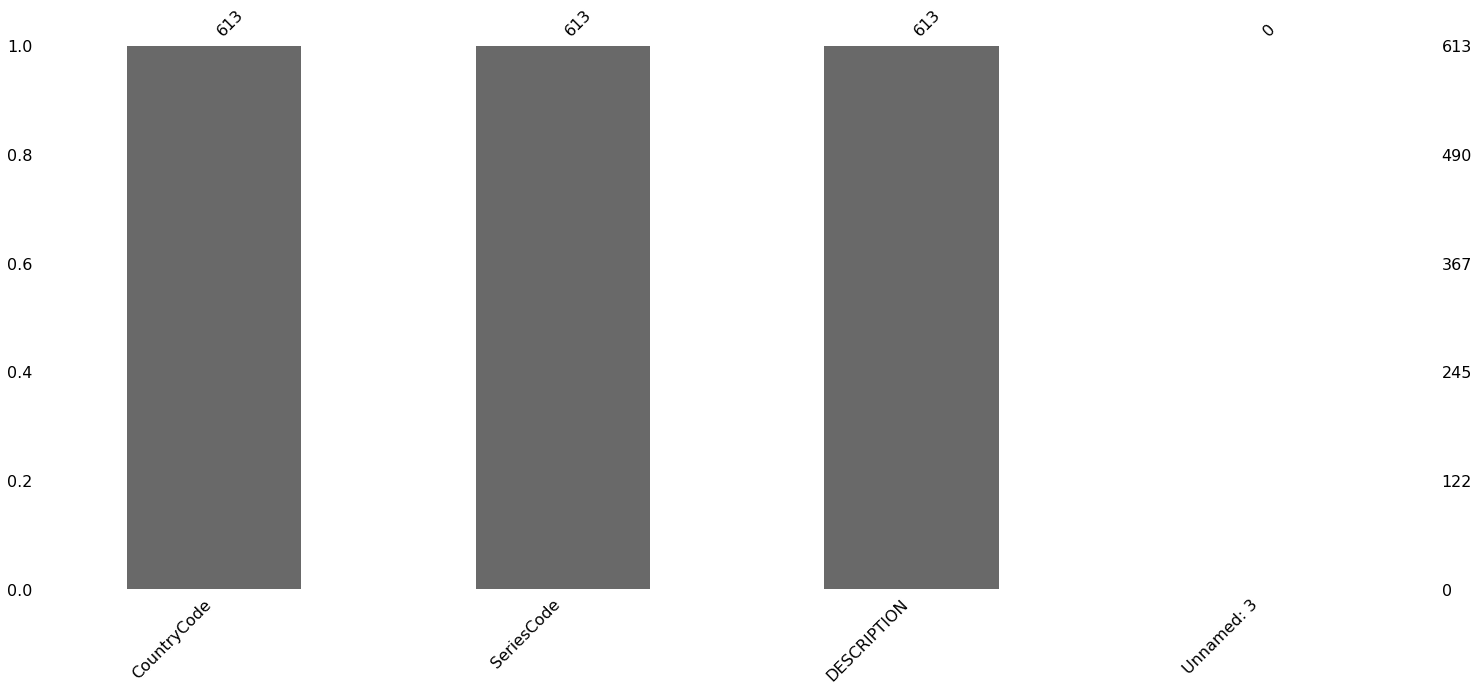

In [247]:
msn.bar(dataseries)

In [15]:
# Doublons avec toutes les colonnes du dataframe
dataseries[dataseries.duplicated(keep=False)].shape[0]

0

# EdStatsFootNote

In [112]:
# Chargement du jeu de données
datafoot = pd.read_csv('EdStatsFootNote.csv', delimiter=',')
datafoot.head(3)

,CountryCode,SeriesCode,Year,DESCRIPTION,Unnamed: 4
0,ABW,SE.PRE.ENRL.FE,YR2001,Country estimation.,NaN
1,ABW,SE.TER.TCHR.FE,YR2005,Country estimation.,NaN
2,ABW,SE.PRE.TCHR.FE,YR2000,Country estimation.,NaN


In [113]:
# Taille : nombre de lignes/colonnes
nRow, nCol = datafoot.shape
print(f'Le jeu de données contient {nRow} lignes et {nCol} colonnes.')

Le jeu de données contient 643638 lignes et 5 colonnes.


In [18]:
#Résumé des variables quantitatives
datafoot.describe()

,Unnamed: 4
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [19]:
# Résumé des variables qualitatives
datafoot.describe(exclude=[np.number])

,CountryCode,SeriesCode,Year,DESCRIPTION
count,643638,643638,643638,643638
unique,239,1558,56,9102
top,LIC,SH.DYN.MORT,YR2004,Country Data
freq,7320,9226,27128,191188


In [253]:
# Valeurs manquantes
nb_na3=datafoot.isnull().sum()
nb_na3[nb_na3>0]

Unnamed: 4    643638
dtype: int64

<AxesSubplot:>

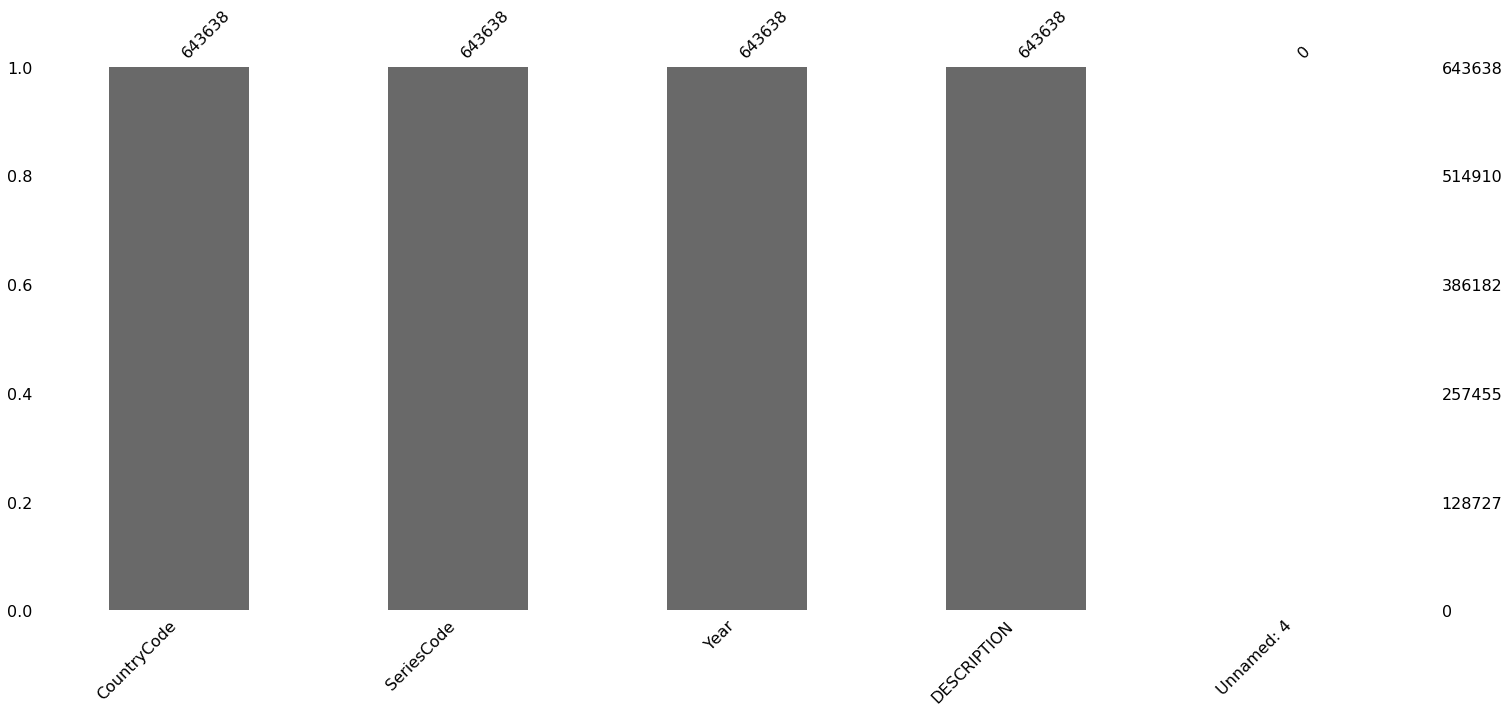

In [254]:
msn.bar(datafoot)

In [255]:
# Doublon avec toutes les colonnes du dataframe
datafoot[datafoot.duplicated(keep=False)].shape[0]

0

# EdStatsSeries

In [114]:
# Chargement du jeu de données
series = pd.read_csv('EdStatsSeries.csv', delimiter=',')
series.head(3)

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,...,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [258]:
series.shape

(3665, 21)

In [260]:
# Résumé des variables qualitatives
series.describe(exclude=[np.number])

,Series Code,Topic,Indicator Name,Short definition,Long definition,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,General comments,Source,Statistical concept and methodology,Development relevance,Related source links
count,3665,3665,3665,2156,3665,99,314,552,47,14,14,3665,23,3,215
unique,3665,37,3665,1169,2060,1,4,14,3,9,8,31,2,1,1
top,BAR.NOED.1519.FE.ZS,Learning Outcomes,Barro-Lee: Percentage of female population age...,Data Interpretation: 1=Latent; 2=Emerging; 3=E...,Data Interpretation: 1=Latent; 2=Emerging; 3=E...,Annual,Projections (2010 to 2100),EGRA,Weighted average,Data should be used cautiously because of diff...,When NEET rates are available for more than tw...,UNESCO Institute for Statistics,TIMSS,Unemployment and total employment are the broa...,http://saber.worldbank.org/index.cfm
freq,1,1046,1,215,215,99,308,403,31,3,3,1269,20,3,215


In [261]:
series.isnull().sum()


Series Code                               0
Topic                                     0
Indicator Name                            0
Short definition                       1509
Long definition                           0
Unit of measure                        3665
Periodicity                            3566
Base Period                            3351
Other notes                            3113
Aggregation method                     3618
Limitations and exceptions             3651
Notes from original source             3665
General comments                       3651
Source                                    0
Statistical concept and methodology    3642
Development relevance                  3662
Related source links                   3450
Other web links                        3665
Related indicators                     3665
License Type                           3665
Unnamed: 20                            3665
dtype: int64

<AxesSubplot:>

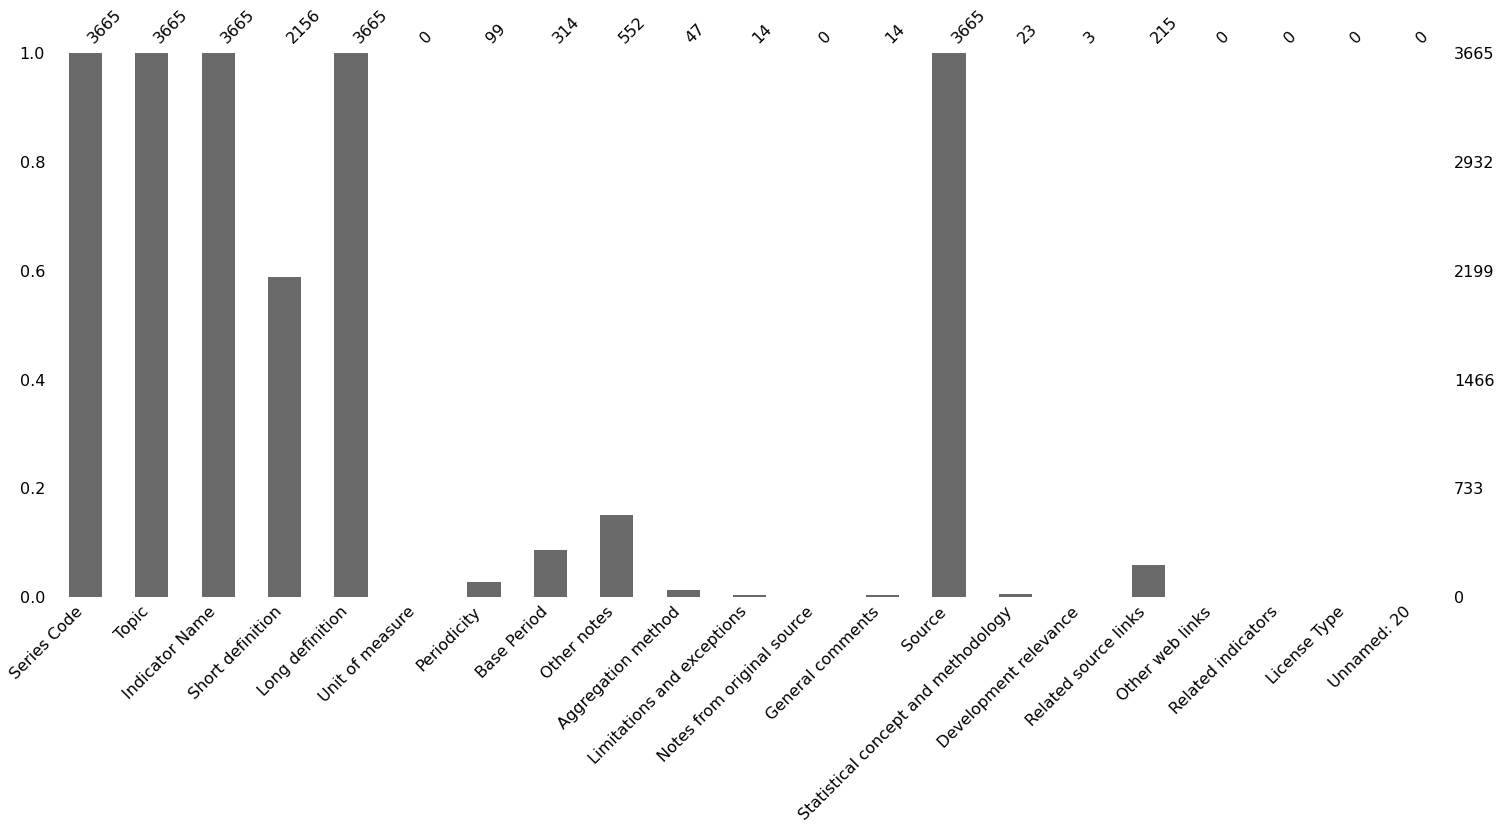

In [262]:
msn.bar(series)

# EdStatsData

In [115]:
Statsdata = pd.read_csv("EdStatsData.csv")
Statsdata.head(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<AxesSubplot:>

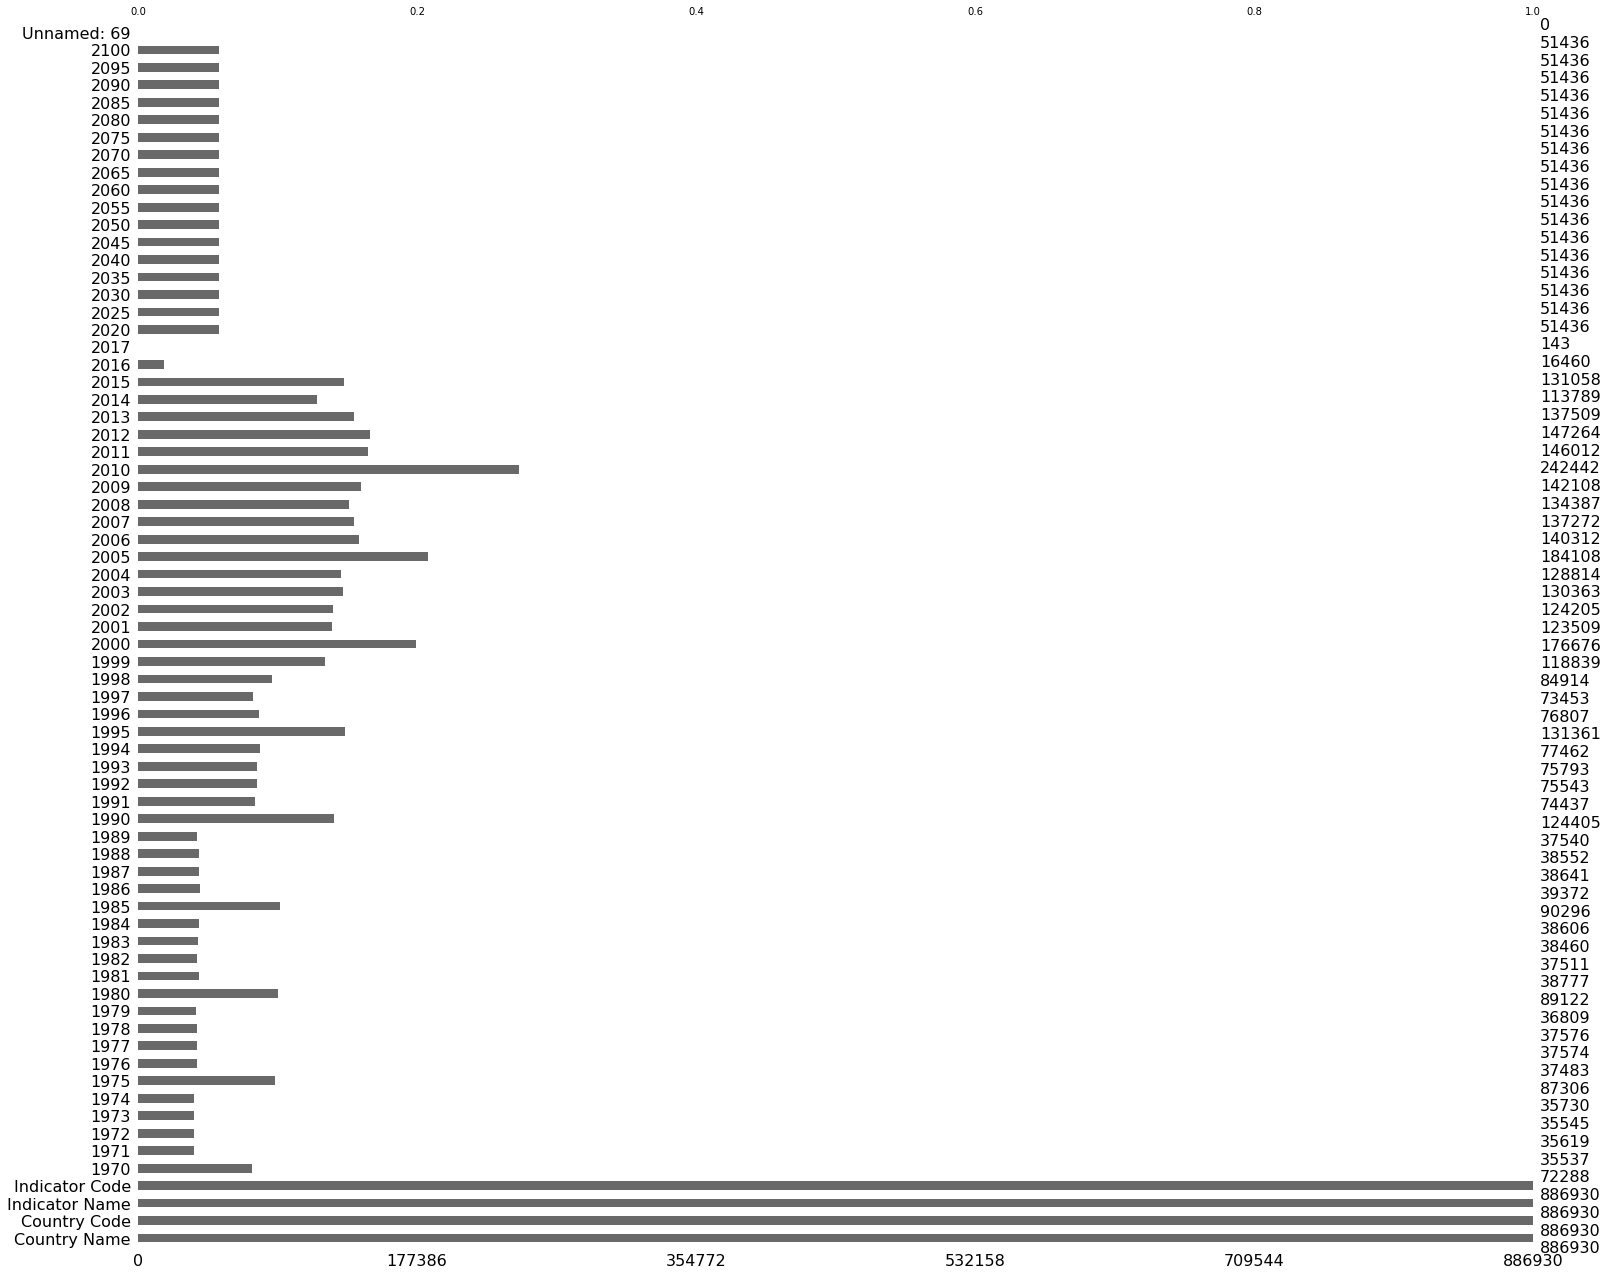

In [116]:
#Proportion des données 
msn.bar(Statsdata)

# Nettoyage des données : 

In [117]:
#Suppression des colonnes vides (Totalement inexploitables)
Statsdata = Statsdata.drop(columns = ['Unnamed: 69'])
dataCountry = dataCountry.drop(['Unnamed: 31'], axis = 1)
dataseries = dataseries.drop(['Unnamed: 3'], axis = 1)
series = series.drop(['Unit of measure','Notes from original source','Other web links','Related indicators' ,'License Type', 'Unnamed: 20'], axis = 1)
datafoot = datafoot.drop(['Unnamed: 4'], axis = 1)

On va réduire notre analyse à certaines années. (Les années qui sont utiles à explorer sont de 2000 à 2015 de par la tranche d'age visée.)

Voyons la répartition du nombre de données en fonctions des années : 

In [118]:
datafoot['Year'] = datafoot['Year'].apply(lambda x : x[2:]) #conversion du format de year


repart = datafoot.groupby('Year').count().reset_index()
fig = px.bar(repart, x = repart['Year'] ,y = repart['CountryCode'],text = "CountryCode", 
             title = "Répartition du nombre de données par années")
fig.update_yaxes(title_text = "Nombre de données")
fig.update_xaxes(title_text = "Années")

In [119]:
Statsdata = Statsdata.drop(columns = ['1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978',
       '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987','1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996',
       '1997', '1998', '2045', '2050', '2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090', '2095', '2100'])
Statsdata

,Country Name,Country Code,Indicator Name,Indicator Code,1999,2000,2001,2002,2003,2004,...,2013,2014,2015,2016,2017,2020,2025,2030,2035,2040
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,76.254318,77.245682,78.800522,80.051399,80.805389,81.607063,...,85.51194,85.320152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886925,Zimbabwe,ZWE,"Youth illiterate population, 15-24 years, male...",UIS.LP.AG15T24.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,199464.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886926,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, b...",SE.ADT.1524.LT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,90.428120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886927,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, f...",SE.ADT.1524.LT.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,93.188350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886928,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, g...",SE.ADT.1524.LT.FM.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.063890,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [120]:
#Suppression des indicateurs vides dans les deux dataframes dataCountry et dataSeries
dataCountry = dataCountry.drop(['2-alpha code', 'Currency Unit', 'Special Notes', 'WB-2 code',
                                'National accounts base year', 'National accounts reference year', 'SNA price valuation',
                                'Lending category', 'Other groups' , 'System of National Accounts', 'Alternative conversion factor',
                                'PPP survey year', 'Balance of Payments Manual in use', 'External debt Reporting status', 'System of trade',
                                'Government Accounting concept', 'IMF data dissemination standard', 'Latest population census',
                                'Latest household survey', 'Source of most recent Income and expenditure data', 'Vital registration complete',
                                'Latest agricultural census', 'Latest industrial data', 'Latest trade data', 'Latest water withdrawal data'], axis = 1)
series = series.drop(['Short definition', 'Periodicity', 'Base Period', 'Other notes', 'Aggregation method',
                              'Limitations and exceptions','General comments', 'Source',
                              'Statistical concept and methodology', 'Development relevance', 'Related source links'],axis = 1)

<AxesSubplot:>

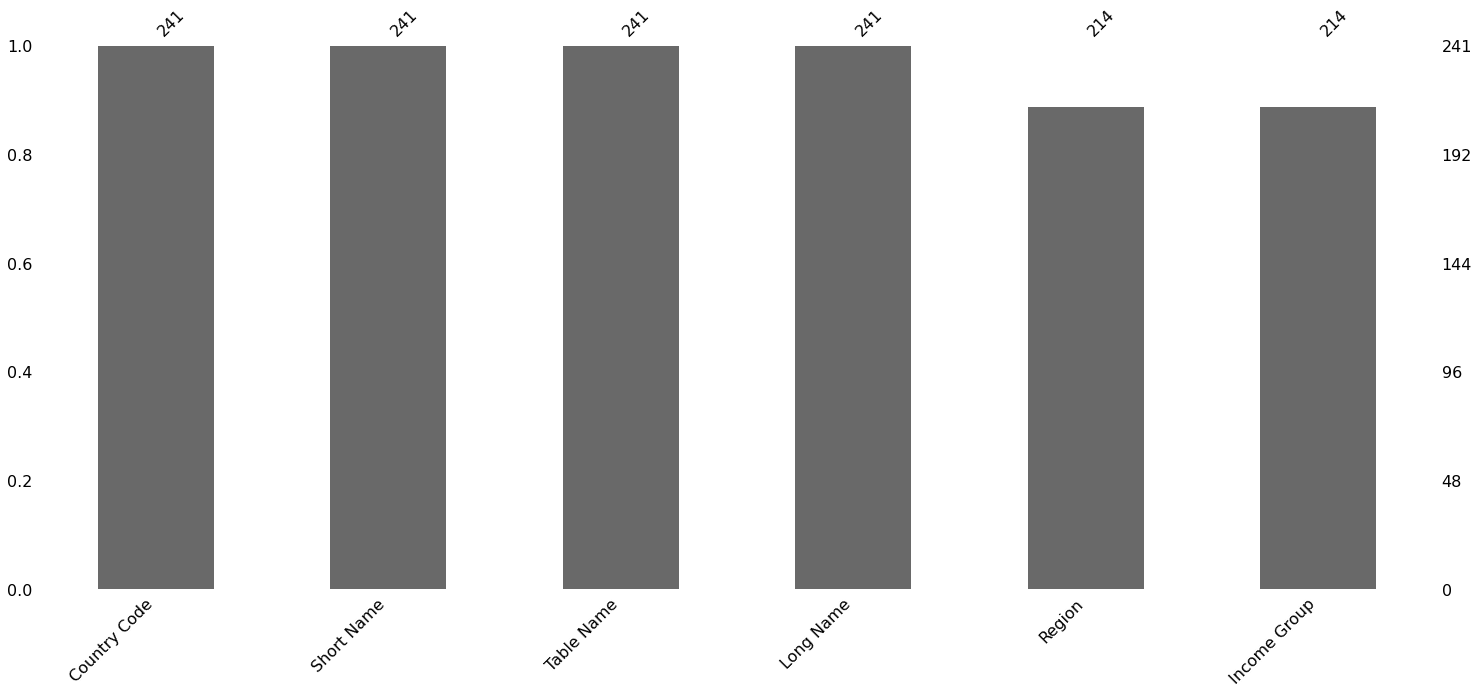

In [121]:
msn.bar(dataCountry)

<AxesSubplot:>

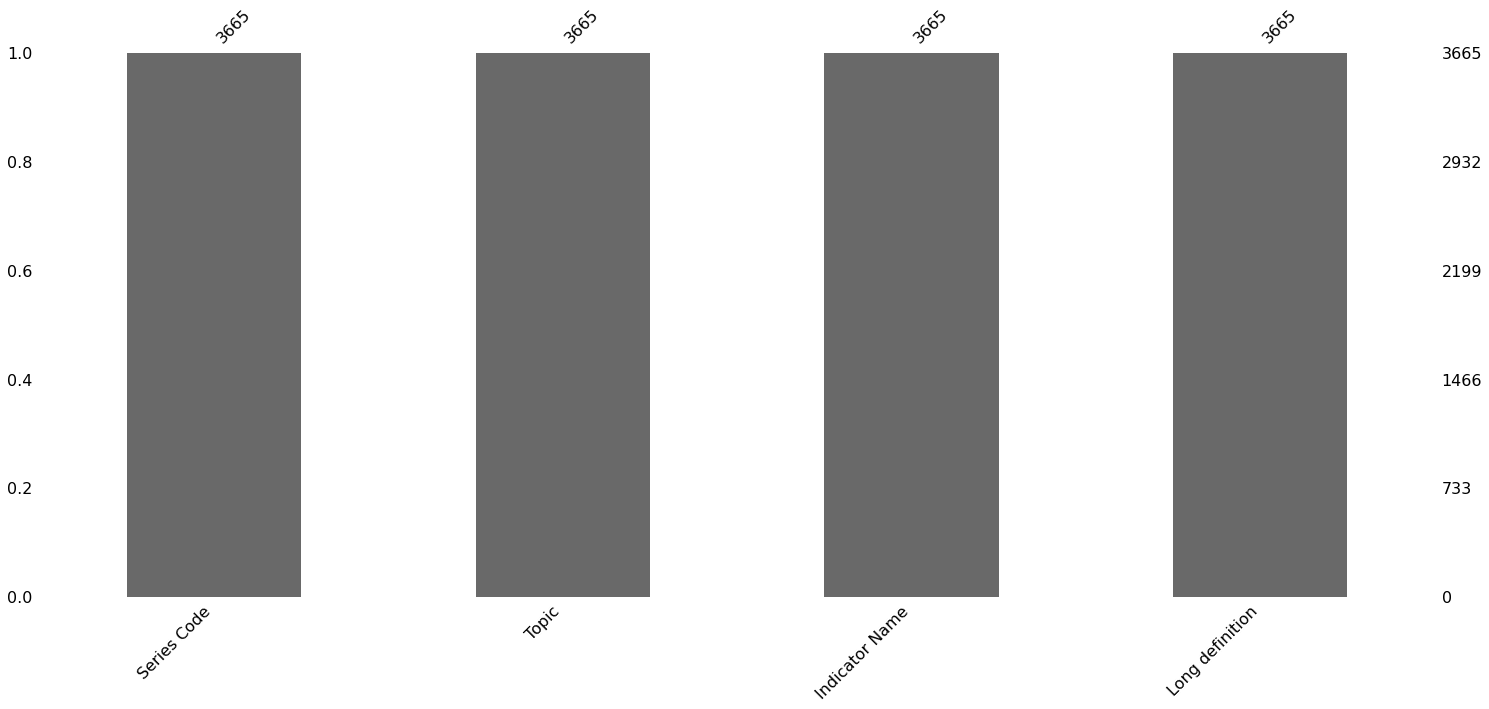

In [122]:
msn.bar(series)

In [272]:
#C"est largement mieux 

In [123]:
#Regroupement des datasets datafoot et series 
seriesfoot = pd.concat([datafoot, series], ignore_index =True)

In [124]:
seriesfoot

,CountryCode,SeriesCode,Year,DESCRIPTION,Series Code,Topic,Indicator Name,Long definition
0,ABW,SE.PRE.ENRL.FE,2001,Country estimation.,NaN,NaN,NaN,NaN
1,ABW,SE.TER.TCHR.FE,2005,Country estimation.,NaN,NaN,NaN,NaN
2,ABW,SE.PRE.TCHR.FE,2000,Country estimation.,NaN,NaN,NaN,NaN
3,ABW,SE.SEC.ENRL.GC,2004,Country estimation.,NaN,NaN,NaN,NaN
4,ABW,SE.PRE.TCHR,2006,Country estimation.,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
647298,NaN,NaN,NaN,NaN,UIS.XUNIT.USCONST.3.FSGOV,Expenditures,Government expenditure per upper secondary stu...,"Average total (current, capital and transfers)..."
647299,NaN,NaN,NaN,NaN,UIS.XUNIT.USCONST.4.FSGOV,Expenditures,Government expenditure per post-secondary non-...,"Average total (current, capital and transfers)..."
647300,NaN,NaN,NaN,NaN,UIS.XUNIT.USCONST.56.FSGOV,Expenditures,Government expenditure per tertiary student (c...,"Average total (current, capital and transfers)..."
647301,NaN,NaN,NaN,NaN,XGDP.23.FSGOV.FDINSTADM.FFD,Expenditures,Government expenditure in secondary institutio...,"Total general (local, regional and central) go..."


In [125]:
#Ajout de la colonne "région" de dataCountry à Statsdata pour des analyses en fonction des régions.
Statsdata = Statsdata.merge( right = dataCountry[['Country Code', 'Region']],on = 'Country Code',how = 'left' )


#Deplacement de la colonne afin de faciliter la lecture
deprégion= Statsdata.pop('Region')
Statsdata.insert(2, 'Region', deprégion)
#Ajout de la colonne "income group" de dataCountry à Statsdata pour des analyses en fonction de l'income.

Statsdata = Statsdata.merge( right = dataCountry[['Country Code', 'Income Group']],on = 'Country Code',how = 'left' )

dépIncome= Statsdata.pop('Income Group')
Statsdata.insert(3, 'Income Group', dépIncome)

Statsdata.columns

Index(['Country Name', 'Country Code', 'Region', 'Income Group',
       'Indicator Name', 'Indicator Code', '1999', '2000', '2001', '2002',
       '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011',
       '2012', '2013', '2014', '2015', '2016', '2017', '2020', '2025', '2030',
       '2035', '2040'],
      dtype='object')

In [126]:
Statsdata.head(5)

,Country Name,Country Code,Region,Income Group,Indicator Name,Indicator Code,1999,2000,2001,2002,...,2013,2014,2015,2016,2017,2020,2025,2030,2035,2040
0,Arab World,ARB,NaN,NaN,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,NaN,NaN,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,NaN,NaN,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,NaN,NaN,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,NaN,NaN,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,76.254318,77.245682,78.800522,80.051399,...,85.51194,85.320152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Regroupement par pays et groupes économiques

In [127]:
#Création d'un dataframe avec uniquement les régions et groupes de pays
Dataregions = dataCountry["Region"].dropna().unique().tolist()

DataGroupe = Statsdata[Statsdata['Country Name'].isin(Dataregions)]
DataGroupe

,Country Name,Country Code,Region,Income Group,Indicator Name,Indicator Code,1999,2000,2001,2002,...,2013,2014,2015,2016,2017,2020,2025,2030,2035,2040
3665,East Asia & Pacific,EAS,NaN,NaN,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3666,East Asia & Pacific,EAS,NaN,NaN,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3667,East Asia & Pacific,EAS,NaN,NaN,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3668,East Asia & Pacific,EAS,NaN,NaN,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3669,East Asia & Pacific,EAS,NaN,NaN,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,9.462442e+01,9.495681e+01,9.541096e+01,9.749242e+01,...,9.609406e+01,9.620796e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80625,Sub-Saharan Africa,SSF,NaN,NaN,"Youth illiterate population, 15-24 years, male...",UIS.LP.AG15T24.M,1.732253e+07,1.732253e+07,1.732253e+07,1.732253e+07,...,2.037019e+07,2.037019e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80626,Sub-Saharan Africa,SSF,NaN,NaN,"Youth literacy rate, population 15-24 years, b...",SE.ADT.1524.LT.ZS,6.813823e+01,6.813823e+01,6.813823e+01,6.813823e+01,...,7.141380e+01,7.141380e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80627,Sub-Saharan Africa,SSF,NaN,NaN,"Youth literacy rate, population 15-24 years, f...",SE.ADT.1524.LT.FE.ZS,6.161780e+01,6.161780e+01,6.161780e+01,6.161780e+01,...,6.636610e+01,6.636610e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80628,Sub-Saharan Africa,SSF,NaN,NaN,"Youth literacy rate, population 15-24 years, g...",SE.ADT.1524.LT.FM.ZS,8.200000e-01,8.200000e-01,8.200000e-01,8.200000e-01,...,8.600000e-01,8.600000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [128]:
#Liste des pays  
countries = Statsdata['Country Name'].drop_duplicates().tolist()

groupe_pays = ['Arab World','East Asia & Pacific',
           'East Asia & Pacific (excluding high income)',
           'European Union',
           'Euro area',
           'Europe & Central Asia',
           'Europe & Central Asia (excluding high income)',
           'High income',
           'Heavily indebted poor countries (HIPC)',
           'Latin America & Caribbean',
           'Latin America & Caribbean (excluding high income)',
           'Least developed countries: UN classification',
           'Low & middle income',
           'Low income',
           'Lower middle income',
           'Middle East & North Africa',
           'Middle East & North Africa (excluding high income)',
           'Middle income',
           'North America',
           'OECD members',
           'South Asia',
           'Sub-Saharan Africa',
           'Sub-Saharan Africa (excluding high income)',
           'Upper middle income',
           'World']
countries = set(countries) - set(groupe_pays)

In [129]:
#Création d'un dataframe avec uniquement les régions et groupes de pays

Statsdata_pays = Statsdata[~Statsdata['Country Name'].isin(groupe_pays)]
Statsdata_pays.reset_index()

,index,Country Name,Country Code,Region,Income Group,Indicator Name,Indicator Code,1999,2000,2001,...,2013,2014,2015,2016,2017,2020,2025,2030,2035,2040
0,91625,Afghanistan,AFG,South Asia,Low income,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,...,47.436790,50.627232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,91626,Afghanistan,AFG,South Asia,Low income,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,...,34.073261,37.641541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,91627,Afghanistan,AFG,South Asia,Low income,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,...,0.567060,0.598370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,91628,Afghanistan,AFG,South Asia,Low income,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,...,60.087059,62.906952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,91629,Afghanistan,AFG,South Asia,Low income,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795300,886925,Zimbabwe,ZWE,Sub-Saharan Africa,Low income,"Youth illiterate population, 15-24 years, male...",UIS.LP.AG15T24.M,NaN,NaN,NaN,...,NaN,199464.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
795301,886926,Zimbabwe,ZWE,Sub-Saharan Africa,Low income,"Youth literacy rate, population 15-24 years, b...",SE.ADT.1524.LT.ZS,NaN,NaN,NaN,...,NaN,90.428120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
795302,886927,Zimbabwe,ZWE,Sub-Saharan Africa,Low income,"Youth literacy rate, population 15-24 years, f...",SE.ADT.1524.LT.FE.ZS,NaN,NaN,NaN,...,NaN,93.188350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
795303,886928,Zimbabwe,ZWE,Sub-Saharan Africa,Low income,"Youth literacy rate, population 15-24 years, g...",SE.ADT.1524.LT.FM.ZS,NaN,NaN,NaN,...,NaN,1.063890,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [130]:
#Répartition des données par pays : 
figure = px.bar(Statsdata_pays.groupby('Country Name')[['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008',
       '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2020', '2025', '2030', '2035', '2040']].count(),
              x = Statsdata_pays.groupby('Country Name')[['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008',
       '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2020', '2025', '2030', '2035', '2040']].count().sum(axis = 1).sort_values(ascending = False).index, 
             y = Statsdata_pays.groupby('Country Name')[['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008',
       '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2020', '2025', '2030', '2035', '2040']].count().sum(axis = 1).sort_values(ascending = False).values,
            title = "Nombre de données par pays",
            width=1000,
    height=500)

figure.update_yaxes(title_text = "Nombre de données renseignées")
figure.update_xaxes(title_text = "Nom du pays")
figure.show()

In [38]:
# la répartition des données par groupes de pays : 
fig = px.bar(DataGroupe.groupby('Country Name')[['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008',
       '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2020', '2025', '2030', '2035', '2040']].count(), 
              y = DataGroupe.groupby('Country Name')[['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008',
       '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2020', '2025', '2030', '2035', '2040']].count().sum(axis = 1).sort_values(ascending = False).values,
              x = DataGroupe.groupby('Country Name')[['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008',
       '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2020', '2025', '2030', '2035', '2040']].count().sum(axis = 1).sort_values().index,
             title = "Nombre de données par groupes de pays" )

fig.update_yaxes(title_text = "Nombre de données")
fig.update_layout(legend_title_text = "Nombre de données par groupes de pays")
fig.update_xaxes(title_text = "Nom  du groupe")
fig.show()

Afin de trouver les pays les moins peuplés on fera notre tri sur l'an 2010 car c'est l'année qui rassemble le plus de données :

In [131]:
popTotale = Statsdata.loc[Statsdata['Indicator Code'] =='SP.POP.TOTL'] #Indicateur démographique

population_min = popTotale.sort_values(by ='2010', ascending = False ) #2010 obtenue grâce au graphe précédent 
population_min

,Country Name,Country Code,Region,Income Group,Indicator Name,Indicator Code,1999,2000,2001,2002,...,2013,2014,2015,2016,2017,2020,2025,2030,2035,2040
90493,World,WLD,NaN,NaN,"Population, total",SP.POP.TOTL,6.038067e+09,6.118075e+09,6.197638e+09,6.276824e+09,...,7.182860e+09,7.268986e+09,7.355220e+09,7.442136e+09,NaN,NaN,NaN,NaN,NaN,NaN
46513,Low & middle income,LMY,NaN,NaN,"Population, total",SP.POP.TOTL,4.974238e+09,5.047579e+09,5.120004e+09,5.192002e+09,...,6.014016e+09,6.093020e+09,6.172291e+09,6.252106e+09,NaN,NaN,NaN,NaN,NaN,NaN
64838,Middle income,MIC,NaN,NaN,"Population, total",SP.POP.TOTL,4.560492e+09,4.622449e+09,4.683010e+09,4.742692e+09,...,5.406029e+09,5.468260e+09,5.530432e+09,5.592833e+09,NaN,NaN,NaN,NaN,NaN,NaN
53843,Lower middle income,LMC,NaN,NaN,"Population, total",SP.POP.TOTL,2.296630e+09,2.337779e+09,2.379054e+09,2.420370e+09,...,2.884574e+09,2.927194e+09,2.970020e+09,3.012924e+09,NaN,NaN,NaN,NaN,NaN,NaN
86828,Upper middle income,UMC,NaN,NaN,"Population, total",SP.POP.TOTL,2.263862e+09,2.284670e+09,2.303956e+09,2.322322e+09,...,2.521455e+09,2.541065e+09,2.560412e+09,2.579910e+09,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
761188,St. Martin (French part),MAF,Latin America & Caribbean,High income: nonOECD,"Population, total",SP.POP.TOTL,2.930500e+04,2.838400e+04,2.778200e+04,2.745000e+04,...,3.126400e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
640243,Palau,PLW,East Asia & Pacific,Upper middle income,"Population, total",SP.POP.TOTL,1.887900e+04,1.917500e+04,1.940400e+04,1.957400e+04,...,2.092000e+04,2.109400e+04,2.128800e+04,2.150300e+04,NaN,NaN,NaN,NaN,NaN,NaN
830823,Tuvalu,TUV,East Asia & Pacific,Upper middle income,"Population, total",SP.POP.TOTL,9.345000e+03,9.420000e+03,9.512000e+03,9.635000e+03,...,1.081900e+04,1.090800e+04,1.100100e+04,1.109700e+04,NaN,NaN,NaN,NaN,NaN,NaN
193113,British Virgin Islands,VGB,NaN,NaN,"Population, total",SP.POP.TOTL,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<AxesSubplot:xlabel='2010', ylabel='Country Name'>

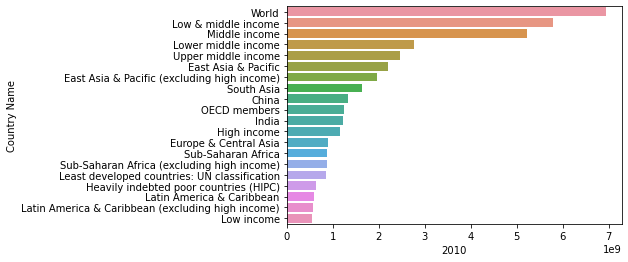

In [132]:
sns.barplot(x = population_min['2010'].head(20), y = population_min['Country Name'].head(20), data = population_min)


In [44]:
population_min['2010'].describe()


count    2.400000e+02
mean     1.948323e+08
std      7.563834e+08
min      1.053100e+04
25%      1.231357e+06
50%      7.733270e+06
75%      3.410045e+07
max      6.930657e+09
Name: 2010, dtype: float64

In [45]:
population_min.nsmallest(1,'2010')


,Country Name,Country Code,Region,Income Group,Indicator Name,Indicator Code,1999,2000,2001,2002,...,2013,2014,2015,2016,2017,2020,2025,2030,2035,2040
830823,Tuvalu,TUV,East Asia & Pacific,Upper middle income,"Population, total",SP.POP.TOTL,9345.0,9420.0,9512.0,9635.0,...,10819.0,10908.0,11001.0,11097.0,NaN,NaN,NaN,NaN,NaN,NaN


In [133]:
#Filtre sur la population 
population_totale = Statsdata[Statsdata['Indicator Code']== 'SP.POP.TOTL']

Filtre_population = population_totale[population_totale['2010'] < 2000000]['Country Name'].tolist()

In [134]:
Statsdata[~Statsdata['Country Name'].isin(Filtre_population)]


,Country Name,Country Code,Region,Income Group,Indicator Name,Indicator Code,1999,2000,2001,2002,...,2013,2014,2015,2016,2017,2020,2025,2030,2035,2040
0,Arab World,ARB,NaN,NaN,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,NaN,NaN,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,NaN,NaN,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,NaN,NaN,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,NaN,NaN,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,76.254318,77.245682,78.800522,80.051399,...,85.51194,85.320152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886925,Zimbabwe,ZWE,Sub-Saharan Africa,Low income,"Youth illiterate population, 15-24 years, male...",UIS.LP.AG15T24.M,NaN,NaN,NaN,NaN,...,NaN,199464.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886926,Zimbabwe,ZWE,Sub-Saharan Africa,Low income,"Youth literacy rate, population 15-24 years, b...",SE.ADT.1524.LT.ZS,NaN,NaN,NaN,NaN,...,NaN,90.428120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886927,Zimbabwe,ZWE,Sub-Saharan Africa,Low income,"Youth literacy rate, population 15-24 years, f...",SE.ADT.1524.LT.FE.ZS,NaN,NaN,NaN,NaN,...,NaN,93.188350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886928,Zimbabwe,ZWE,Sub-Saharan Africa,Low income,"Youth literacy rate, population 15-24 years, g...",SE.ADT.1524.LT.FM.ZS,NaN,NaN,NaN,NaN,...,NaN,1.063890,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [135]:
#Nombre d'indicateurs par pays
seriesfoot.groupby('CountryCode')[['SeriesCode']].count().sort_values(by = ['SeriesCode'])


,SeriesCode
CountryCode,
FRO,2
MNP,4
XKX,12
CUW,23
IMN,32
...,...
SSF,6336
SSA,6389
LDC,6481


In [136]:
#Graphe représentant le nombre d'indicateurs par pays :
fig = px.bar(seriesfoot.groupby('CountryCode')[['SeriesCode']].count().sort_values(by = ['SeriesCode'], ascending = False), 
             x = seriesfoot.groupby('CountryCode')[['SeriesCode']].count().sum(axis = 1).sort_values().index,
             y = seriesfoot.groupby('CountryCode')[['SeriesCode']].count().sum(axis = 1).sort_values(ascending = False).values,
             title = "Nombre d'indicateurs par pays",
            width=2000,
    height=500)

fig.update_yaxes(title_text = "Nombre d'indicateurs")
fig.update_layout(legend_title_text = "Nombre d'indicateurs par pays")
fig.update_xaxes(title_text = " Code Pays")
fig.show()

# Sélection des indicateurs pertinents :

In [137]:
indicateurs_pertinents = ['SE.TER.ENRL',
                         'UIS.E.3',
                         'IT.NET.USER.P2',
                        'IT.CMP.PCMP.P2',
                        'SE.XPD.TOTL.GD.ZS',
                        'SP.POP.1524.TO.UN']

series[series['Series Code'].isin(indicateurs_pertinents)][['Series Code','Indicator Name','Long definition']]


,Series Code,Indicator Name,Long definition
610,IT.CMP.PCMP.P2,Personal computers (per 100 people),Personal computers are self-contained computer...
611,IT.NET.USER.P2,Internet users (per 100 people),Internet users are individuals who have used t...
2332,SE.TER.ENRL,"Enrolment in tertiary education, all programme...",The total number of students enrolled at publi...
2381,SE.XPD.TOTL.GD.ZS,Government expenditure on education as % of GD...,"Total general (local, regional and central) go..."
2506,SP.POP.1524.TO.UN,"Population, ages 15-24, total","Population, ages 15-24, total is the total pop..."
2825,UIS.E.3,"Enrolment in upper secondary education, both s...",Total number of students enrolled in public an...


In [138]:
filtre_indicateurs = Statsdata[Statsdata['Indicator Code'].isin(indicateurs_pertinents)]


<AxesSubplot:>

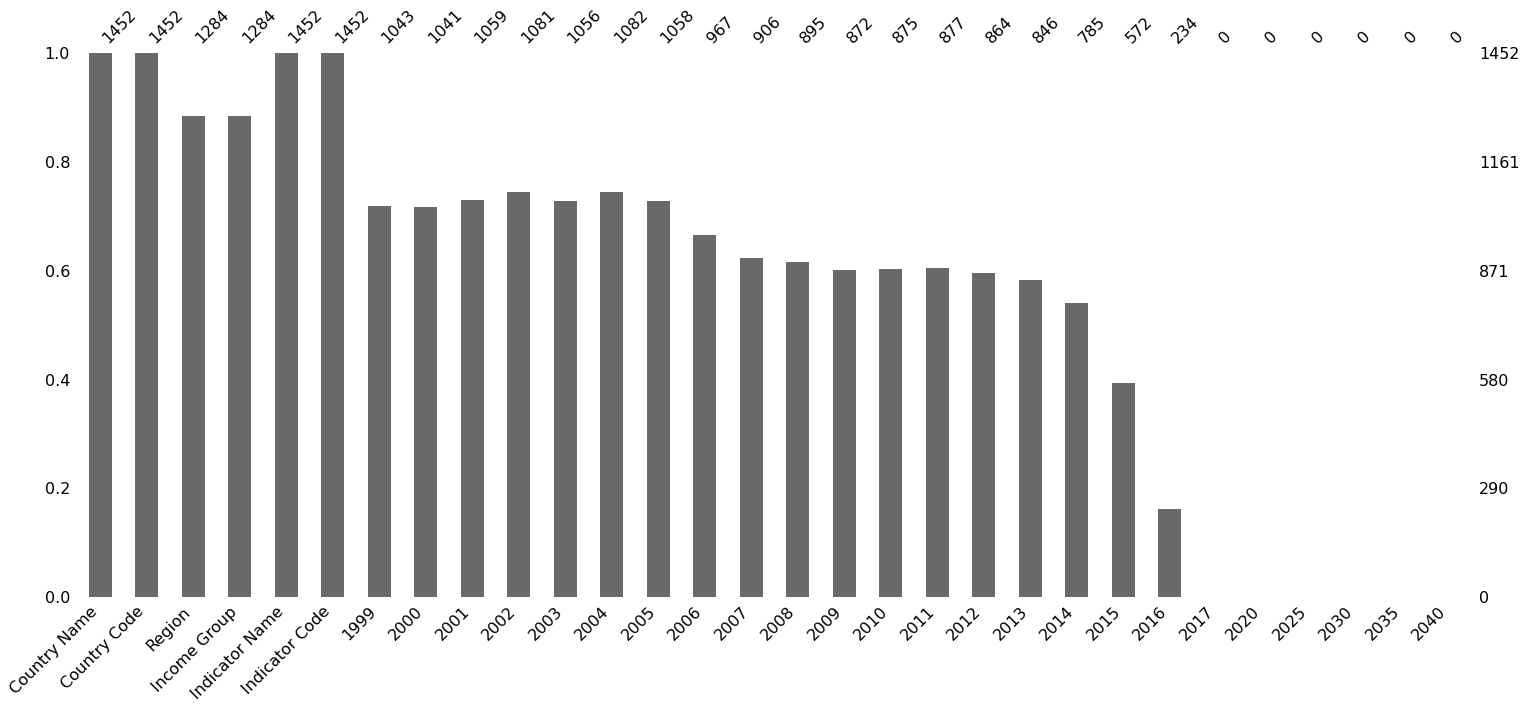

In [139]:
#la proportion des valeurs dans les indicateurs cibles 
msn.bar(filtre_indicateurs)


In [140]:
filtre_indicateurs.shape


(1452, 30)

In [141]:
# fonction qui récupère la derniere valeur non nulle pour chaque indicateur
def derniere_valeur(A) :
    if A.last_valid_index() == 'None' : 
        return 'None'
    else :
        return A[A.last_valid_index()]

In [142]:
#On supprime les colonnes entre 2017 et 2040 où les données sont complètement absentes : 

years = [str(i) for i in range(1999 , 2016)]
mydata = filtre_indicateurs.dropna(how = 'all', subset = years )
cols_à_supp = ['2017','2020', '2025','2030', '2035','2040']
mydata.drop(cols_à_supp, axis =1,  inplace = True )
mydata

C:\Users\asus\AppData\Local\Temp\ipykernel_18684\935714462.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Country Name,Country Code,Region,Income Group,Indicator Name,Indicator Code,1999,2000,2001,2002,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
1204,Arab World,ARB,NaN,NaN,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,4.875952e+06,5.089854e+06,5.400639e+06,5.798696e+06,...,7.588664e+06,8.006892e+06,8.382284e+06,8.715273e+06,8.594488e+06,9.147083e+06,9.688632e+06,9.966484e+06,NaN,NaN
1214,Arab World,ARB,NaN,NaN,"Enrolment in upper secondary education, both s...",UIS.E.3,8.190412e+06,8.554936e+06,9.096402e+06,9.393456e+06,...,1.037482e+07,1.030286e+07,1.017877e+07,1.064478e+07,1.162018e+07,1.202761e+07,1.202161e+07,1.199598e+07,NaN,NaN
1375,Arab World,ARB,NaN,NaN,Internet users (per 100 people),IT.NET.USER.P2,5.985821e-01,1.139541e+00,1.561288e+00,2.693061e+00,...,1.420590e+01,1.859353e+01,2.297369e+01,2.674725e+01,2.970776e+01,3.401422e+01,3.686860e+01,NaN,NaN,NaN
2084,Arab World,ARB,NaN,NaN,Personal computers (per 100 people),IT.CMP.PCMP.P2,1.707795e+00,1.887733e+00,2.414015e+00,2.517600e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4869,East Asia & Pacific,EAS,NaN,NaN,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,2.367350e+07,2.525746e+07,2.780141e+07,3.120186e+07,...,4.689837e+07,4.929505e+07,5.267760e+07,5.523363e+07,5.658473e+07,5.887421e+07,6.091618e+07,6.909780e+07,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884479,Zimbabwe,ZWE,Sub-Saharan Africa,Low income,"Enrolment in upper secondary education, both s...",UIS.E.3,3.910800e+05,4.082510e+05,4.149700e+05,4.035090e+05,...,NaN,NaN,NaN,NaN,NaN,4.810060e+05,4.905220e+05,NaN,NaN,NaN
884525,Zimbabwe,ZWE,Sub-Saharan Africa,Low income,Government expenditure on education as % of GD...,SE.XPD.TOTL.GD.ZS,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.973330e+00,NaN,8.383220e+00,8.485360e+00,8.429330e+00,NaN,NaN
884640,Zimbabwe,ZWE,Sub-Saharan Africa,Low income,Internet users (per 100 people),IT.NET.USER.P2,1.616755e-01,4.014335e-01,7.998460e-01,1.100000e+00,...,3.000000e+00,3.500000e+00,4.000000e+00,6.400000e+00,8.400000e+00,1.200000e+01,1.550000e+01,1.636474e+01,2.274282e+01,23.119989
885349,Zimbabwe,ZWE,Sub-Saharan Africa,Low income,Personal computers (per 100 people),IT.CMP.PCMP.P2,1.211169e+00,1.559544e+00,1.588971e+00,4.746489e+00,...,NaN,7.431140e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [143]:
mydata = mydata.merge(pd.DataFrame(mydata.apply(derniere_valeur,axis = 1)).rename(columns = {0 : 'Last_Value'}),
           left_index = True, right_index=True)[['Country Name','Country Code','Region','Income Group','Indicator Name','Indicator Code', 'Last_Value']]
mydata

,Country Name,Country Code,Region,Income Group,Indicator Name,Indicator Code,Last_Value
1204,Arab World,ARB,NaN,NaN,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,9.966484e+06
1214,Arab World,ARB,NaN,NaN,"Enrolment in upper secondary education, both s...",UIS.E.3,1.199598e+07
1375,Arab World,ARB,NaN,NaN,Internet users (per 100 people),IT.NET.USER.P2,3.686860e+01
2084,Arab World,ARB,NaN,NaN,Personal computers (per 100 people),IT.CMP.PCMP.P2,6.676681e+00
4869,East Asia & Pacific,EAS,NaN,NaN,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,6.909780e+07
...,...,...,...,...,...,...,...
884479,Zimbabwe,ZWE,Sub-Saharan Africa,Low income,"Enrolment in upper secondary education, both s...",UIS.E.3,4.905220e+05
884525,Zimbabwe,ZWE,Sub-Saharan Africa,Low income,Government expenditure on education as % of GD...,SE.XPD.TOTL.GD.ZS,8.429330e+00
884640,Zimbabwe,ZWE,Sub-Saharan Africa,Low income,Internet users (per 100 people),IT.NET.USER.P2,2.311999e+01
885349,Zimbabwe,ZWE,Sub-Saharan Africa,Low income,Personal computers (per 100 people),IT.CMP.PCMP.P2,7.431140e+00


In [144]:
pivot_table_mydata = pd.pivot_table(mydata, values='Last_Value', index=['Country Name','Country Code','Region','Income Group'],
                    columns=['Indicator Code'])
pivot_table_mydata.reset_index(inplace = True)

In [145]:
#On renomme les indicateurs pour faciliter la lecture
pivot_table_mydata = pivot_table_mydata.rename(columns = {'IT.CMP.PCMP.P2' : 'COMP', 'IT.NET.USER.P2' : 'NET', 'SE.TER.ENRL' : 'TER', 'SE.XPD.TOTL.GD.ZS' : 'GDP', 'SP.POP.1524.TO.UN' : 'POP', 'UIS.E.3' : 'SEC'})


In [147]:
#Taux de remplissage des indicateurs
fig = px.bar(mydata[['Indicator Name', 'Indicator Code', 'Last_Value']].groupby(['Indicator Name', 'Indicator Code']).count().reset_index().sort_values(by='Last_Value',ascending=False),
             x = 'Indicator Name',y ='Last_Value' ,
            title = "Nombre de données par indicateurs")

fig.update_yaxes(title_text = "Nombre de données")
fig.update_xaxes(title_text = "Indicateurs")
fig.show()


<AxesSubplot:xlabel='Indicator Code'>

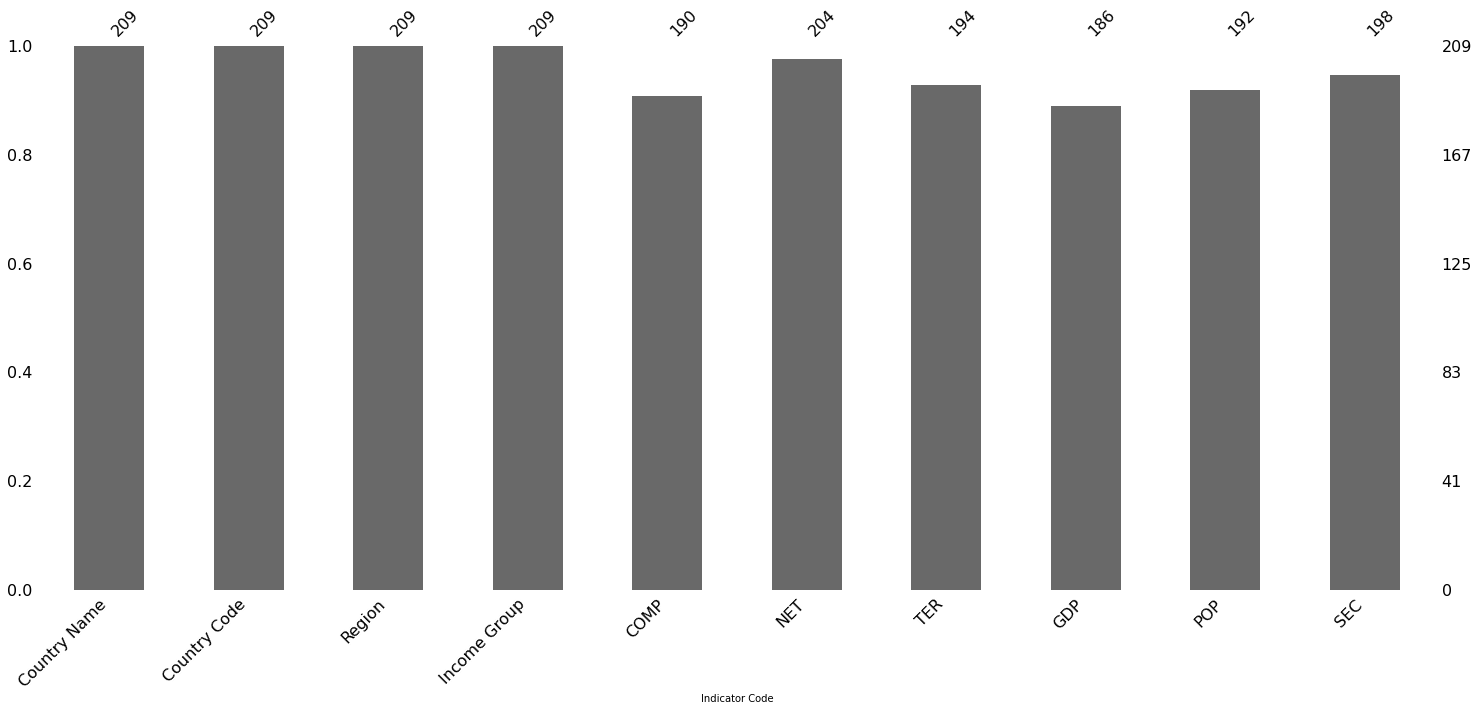

In [148]:
msn.bar(pivot_table_mydata)

# Statistiques descriptives pour chaque indicateur :


In [149]:
#Stat descriptives par indicateur
pivot_table_mydata.describe()

Indicator Code,COMP,NET,TER,GDP,POP,SEC
count,190.000000,204.000000,1.940000e+02,186.000000,1.920000e+02,1.980000e+02
mean,17.019329,50.933562,1.093571e+06,4.706620,6.274290e+06,1.246907e+06
std,22.186224,28.517594,4.205141e+06,2.123730,2.338922e+07,5.171082e+06
min,0.022211,0.000000,1.940000e+02,1.021950,2.825000e+03,3.530000e+02
25%,2.183655,25.336288,1.924950e+04,3.196162,2.945968e+05,3.463500e+04
50%,7.829152,53.226475,1.713925e+05,4.541055,1.158544e+06,1.786935e+05
75%,20.773356,76.126684,4.793825e+05,5.520422,4.519916e+06,7.234760e+05
max,96.170657,98.240016,4.336739e+07,12.837270,2.441202e+08,5.522868e+07


In [150]:
#Matrice de corrélation des indicateurs 
fig = px.scatter_matrix(pivot_table_mydata,
                        dimensions=["NET", "SEC", "TER", "COMP", "GDP", "POP"], width=1000,height = 1000)
fig.update_traces(diagonal_visible=False)
fig.show()

In [153]:
indic_name = mydata["Indicator Name"].unique().tolist()
#mise en place d'abrévations en relation avec data_pivot pour la liste des indicateurs 
ind = {'IT.CMP.PCMP.P2' : 'COMP',
           'IT.NET.USER.P2' : 'NET',
           'SE.TER.ENRL' : 'TER',
           'SE.XPD.TOTL.GD.ZS' : 'GDP',
           'SP.POP.1524.TO.UN' : 'POP',
           'UIS.E.3' : 'SEC'}
indicateurs_pertinents= [ind.get(n,n) for n in indicateurs_pertinents]

#Création d'un dictionnaire reliant les indicateurs et leur nom complet
dict_indic = dict(zip(indicateurs_pertinents,indic_name))
print(dict_indic)

{'TER': 'Enrolment in tertiary education, all programmes, both sexes (number)', 'SEC': 'Enrolment in upper secondary education, both sexes (number)', 'NET': 'Internet users (per 100 people)', 'COMP': 'Personal computers (per 100 people)', 'GDP': 'Government expenditure on education as % of GDP (%)', 'POP': 'Population, ages 15-24, total'}


In [154]:
#Histogrammes et boxplot pour chaque indicateurs
for (key, value)  in dict_indic.items() :
    fig =  px.histogram(
   pivot_table_mydata, x= key ,
    nbins = 30,
    marginal = 'box',
    title = value)
    fig.show()

In [77]:
px.scatter(pivot_table_mydata, x='NET' , y ='POP' ,log_y = True,  hover_data = ['Country Name'], color = 'Region', title = "Repartition du taux d'accès à l'internet en fonction de la population")


In [78]:
px.scatter(pivot_table_mydata, x='COMP' , y ='POP' ,log_y = True,  hover_data = ['Country Name'], color = 'Region', title = "Repartition du taux de détenteurs d'ordinateurs personnel en fonction de la population ")


Les pays qui réunissent les deux critères sont :

l'Allemagne
la Norvège
l'Autriche
Hong Kong SAR, Chine
Singapour
la France
l'Arabie Saoudite
les Etats Unis
l'Angleterre
le Canada
etc ...

In [80]:
px.scatter(pivot_table_mydata, x='GDP' , y ='POP' ,log_y = True,  hover_data = ['Country Name'], color = 'Region', title = "Repartition du taux d'investissement du gouvernement dans l'éducation en fonction de la population ")


# Statistiques par régions

In [155]:
for (indicator, name)  in dict_indic.items() :
    indicator = pivot_table_mydata[[indicator, 'Region']].groupby('Region', as_index = True).describe()
    indicator.reset_index(inplace = True)
    print( f"For the {name} ")
    display(indicator)

For the Enrolment in tertiary education, all programmes, both sexes (number) 


Indicator Code                      Region   TER                              \
                                           count          mean           std   
0                      East Asia & Pacific  29.0  2.371874e+06  8.010889e+06   
1                    Europe & Central Asia  51.0  7.393062e+05  1.341163e+06   
2                Latin America & Caribbean  36.0  6.941844e+05  1.558316e+06   
3               Middle East & North Africa  21.0  7.187397e+05  1.155227e+06   
4                            North America   3.0  6.914954e+06  1.094322e+07   
5                               South Asia   8.0  4.634772e+06  1.113027e+07   
6                       Sub-Saharan Africa  46.0  1.686235e+05  2.924237e+05   

Indicator Code                                                         
                   min        25%        50%          75%         max  
0                668.0    9943.00   217364.0   1453521.00  43367392.0  
1                501.0  108070.00   265679.0    523199.00   6592416.0  
2                194.0    4766.50   135081.0    395031.25   8285475.0  
3               4705.0  126947.00   312750.0    772877.00   4802721.0  
4                973.0  606567.00  1212161.0  10371944.50  19531728.0  
5               6089.0  199291.25   376662.0   1920770.00  32107420.0  
6               1003.0   12542.00    54126.5    163612.50   1513371.0

For the Enrolment in upper secondary education, both sexes (number) 


Indicator Code                      Region   SEC                              \
                                           count          mean           std   
0                      East Asia & Pacific  30.0  2.301114e+06  8.051461e+06   
1                    Europe & Central Asia  52.0  6.864309e+05  1.084600e+06   
2                Latin America & Caribbean  38.0  6.617239e+05  1.754832e+06   
3               Middle East & North Africa  21.0  7.235323e+05  1.039395e+06   
4                            North America   3.0  4.423299e+06  6.379245e+06   
5                               South Asia   8.0  8.679094e+06  1.893097e+07   
6                       Sub-Saharan Africa  46.0  4.155972e+05  8.143874e+05   

Indicator Code                                                          
                    min        25%        50%          75%         max  
0                 353.0   14285.00   128812.5  1209855.000  43709224.0  
1                1288.0   92871.75   260119.0   563130.000   4995623.0  
2                 800.0    5788.50   119883.0   539399.000   9949583.0  
3               17418.0  108681.00   355009.0   730640.000   3691835.0  
4                2188.0  766790.50  1531393.0  6633854.000  11736315.0  
5                2737.0  731760.50  1300636.0  5065563.625  55228676.0  
6                2624.0   47511.00   141604.5   311287.000   4046541.0

For the Internet users (per 100 people) 


...

Indicator Code                      Region  COMP                        \
                                           count       mean        std   
0                      East Asia & Pacific  30.0  18.879208  22.523648   
1                    Europe & Central Asia  47.0  33.750170  27.641965   
2                Latin America & Caribbean  36.0  10.227111   6.217086   
3               Middle East & North Africa  21.0  15.602573  16.764546   
4                            North America   3.0  65.552941  38.159145   
5                               South Asia   8.0   4.052155   6.494048   
6                       Sub-Saharan Africa  45.0   3.469602   5.546605   

Indicator Code                                                         
                      min        25%        50%        75%        max  
0                0.378256   4.912923   7.938075  25.382099  72.061563  
1                0.817567   9.652940  26.150248  56.425799  96.170657  
2                0.877393   4.949887  10.008749  14.759333  23.147452  
3                0.792447   4.501956   9.595860  21.998651  65.234645  
4               22.296631  51.106060  79.915488  87.181097  94.446705  
5                0.390148   0.504992   2.183200   3.313849  19.813424  
6                0.022211   0.646019   1.081776   3.726937  24.030374

For the Government expenditure on education as % of GDP (%) 


Indicator Code                      Region   GDP                               \
                                           count      mean       std      min   
0                      East Asia & Pacific  27.0  5.408905  3.073869  1.88730   
1                    Europe & Central Asia  49.0  4.738525  1.610514  1.02195   
2                Latin America & Caribbean  35.0  4.948381  1.966679  2.04457   
3               Middle East & North Africa  19.0  4.323963  1.564227  1.32232   
4                            North America   3.0  4.122100  2.094468  1.70430   
5                               South Asia   8.0  3.776182  1.789558  1.92634   
6                       Sub-Saharan Africa  45.0  4.428418  2.275657  1.09972   

Indicator Code                                         
                     25%      50%       75%       max  
0               3.455960  4.59987  6.013810  12.46775  
1               3.861330  4.76626  5.499550   8.62711  
2               3.405170  4.93095  5.930850  12.83727  
3               3.268090  4.48079  5.141620   7.84900  
4               3.492760  5.28122  5.331000   5.38078  
5               2.529835  3.51485  4.187647   7.36169  
6               2.757560  3.75682  5.607990  11.36114

For the Population, ages 15-24, total 


Indicator Code                      Region   POP                              \
                                           count          mean           std   
0                      East Asia & Pacific  30.0  1.113271e+07  3.616593e+07   
1                    Europe & Central Asia  48.0  2.250838e+06  3.340220e+06   
2                Latin America & Caribbean  35.0  3.044773e+06  6.553111e+06   
3               Middle East & North Africa  21.0  3.530033e+06  4.389639e+06   
4                            North America   3.0  1.650938e+07  2.489726e+07   
5                               South Asia   8.0  4.185906e+07  8.314867e+07   
6                       Sub-Saharan Africa  47.0  4.203060e+06  6.420711e+06   

Indicator Code                                                            
                    min         25%        50%          75%          max  
0                2825.0    66255.50   767924.5   6175581.25  197026759.0  
1                4251.0   500085.25   999616.0   2066230.75   14661984.0  
2                5789.0    49422.50   850912.0   2430972.50   33595574.0  
3               51504.0   583565.00  1211599.0   5995687.00   15377746.0  
4                7102.0  2190306.50  4373511.0  24760514.00   45147517.0  
5               69984.0  2277826.50  7032757.5  35570648.25  244120201.0  
6               14460.0   512427.50  2265841.0   4604884.50   36659023.0

In [157]:
#Indicateurs numériques
# Accès à l'informatique
#Barplot
fig = px.bar(pivot_table_mydata.groupby('Region').mean()['COMP'], x = pivot_table_mydata.groupby('Region').mean()['COMP'].index,
             y= pivot_table_mydata.groupby('Region').mean()['COMP'].sort_values(ascending = False).values,
            title = "Moyenne par région du taux des detenteurs d'ordinateurs personnels en % ")
fig.update_yaxes(title_text = " Pourcentage moyen d'utilisateurs d'internet ")
fig.update_xaxes(title_text = "Region")
fig.show()
#Boite à moustache
fig1 = px.box(pivot_table_mydata, y = "COMP", x = "Region",
              title = "Répartition par région du taux des detenteurs d'ordinateurs personnels en % ")
fig1.show()

In [311]:
#Barplot
fig = px.bar(pivot_table_mydata.groupby('Region').mean()['NET'],
             x =pivot_table_mydata.groupby('Region').mean()['NET'].index,
             y =pivot_table_mydata.groupby('Region').mean()['NET'].sort_values(ascending = False).values,
            title = "Répartition par région de la moyenne du taux d'accés à l'internet en %")
fig.update_yaxes(title_text = "pourcentage moyen du taux d'accés à l'internet ")
fig.update_xaxes(title_text = "Region")
fig.show()
#Boîte à moustache 
fig1 = px.box(pivot_table_mydata, y = "NET", x = "Region",
             title = "Répartition par région du taux d'accés à l'internet en %")
fig1.show()

In [158]:
pivot_table_mydata.nsmallest(1,"NET")


Indicator Code,Country Name,Country Code,Region,Income Group,COMP,NET,TER,GDP,POP,SEC
98,"Korea, Dem. People’s Rep.",PRK,East Asia & Pacific,Low income,NaN,0.0,565350.0,NaN,4023348.0,1245086.0


In [159]:
Ter = pivot_table_mydata[['TER','Region']].groupby('Region',as_index = True).describe()
Ter.reset_index(inplace = True)
Ter

Indicator Code                      Region   TER                              \
                                           count          mean           std   
0                      East Asia & Pacific  29.0  2.371874e+06  8.010889e+06   
1                    Europe & Central Asia  51.0  7.393062e+05  1.341163e+06   
2                Latin America & Caribbean  36.0  6.941844e+05  1.558316e+06   
3               Middle East & North Africa  21.0  7.187397e+05  1.155227e+06   
4                            North America   3.0  6.914954e+06  1.094322e+07   
5                               South Asia   8.0  4.634772e+06  1.113027e+07   
6                       Sub-Saharan Africa  46.0  1.686235e+05  2.924237e+05   

Indicator Code                                                         
                   min        25%        50%          75%         max  
0                668.0    9943.00   217364.0   1453521.00  43367392.0  
1                501.0  108070.00   265679.0    523199.00   6592416.0  
2                194.0    4766.50   135081.0    395031.25   8285475.0  
3               4705.0  126947.00   312750.0    772877.00   4802721.0  
4                973.0  606567.00  1212161.0  10371944.50  19531728.0  
5               6089.0  199291.25   376662.0   1920770.00  32107420.0  
6               1003.0   12542.00    54126.5    163612.50   1513371.0

In [160]:
#indicateur demographique
fig = px.bar(pivot_table_mydata.groupby('Region').mean()['TER'],
             x= pivot_table_mydata.groupby('Region').mean()['TER'].index,
             y=pivot_table_mydata.groupby('Region').mean()['TER'].sort_values(ascending = False).values ,
             title = "Repartition par région de la moyenne du nombre d'inscrits à l'université")

fig.update_yaxes(title_text = "nombre moyen d'étudiants ")
fig.update_xaxes(title_text = "Region")
fig.show()

#Boîte à moustache 
fig1 = px.box(pivot_table_mydata, y = "TER", x = "Region",
             title = "Repartition par région du nombre d'inscrits à l'université")
fig1.show()

In [161]:
fig = px.bar(pivot_table_mydata.groupby('Region').mean()['SEC'],
             x= pivot_table_mydata.groupby('Region').mean()['SEC'].index,
             y= pivot_table_mydata.groupby('Region').mean()['SEC'].sort_values(ascending = False).values ,
            title = "Repartition par région de la moyenne du nombre d'inscrits au lycée")
fig.update_yaxes(title_text = "moyenne du nombre de lycéens ")
fig.update_xaxes(title_text = "Region")
fig.show()
#Boîte à moustache 
fig1 = px.box(pivot_table_mydata, y = "SEC", x = "Region", title ="Repartition par région du nombre d'inscrits au lycée")
fig1.show()

In [162]:
Pop = pivot_table_mydata[['POP','Region']].groupby('Region',as_index = True).describe()
Pop.reset_index(inplace = True)
Pop

Indicator Code                      Region   POP                              \
                                           count          mean           std   
0                      East Asia & Pacific  30.0  1.113271e+07  3.616593e+07   
1                    Europe & Central Asia  48.0  2.250838e+06  3.340220e+06   
2                Latin America & Caribbean  35.0  3.044773e+06  6.553111e+06   
3               Middle East & North Africa  21.0  3.530033e+06  4.389639e+06   
4                            North America   3.0  1.650938e+07  2.489726e+07   
5                               South Asia   8.0  4.185906e+07  8.314867e+07   
6                       Sub-Saharan Africa  47.0  4.203060e+06  6.420711e+06   

Indicator Code                                                            
                    min         25%        50%          75%          max  
0                2825.0    66255.50   767924.5   6175581.25  197026759.0  
1                4251.0   500085.25   999616.0   2066230.75   14661984.0  
2                5789.0    49422.50   850912.0   2430972.50   33595574.0  
3               51504.0   583565.00  1211599.0   5995687.00   15377746.0  
4                7102.0  2190306.50  4373511.0  24760514.00   45147517.0  
5               69984.0  2277826.50  7032757.5  35570648.25  244120201.0  
6               14460.0   512427.50  2265841.0   4604884.50   36659023.0

In [163]:
fig4 = px.bar(pivot_table_mydata.groupby('Region').mean()['POP'],
             x= pivot_table_mydata.groupby('Region').mean()['POP'].index,
             y=pivot_table_mydata.groupby('Region').mean()['POP'].sort_values(ascending = False).values ,
            title = "Répartition par régions de la moyenne de la population des 15-24 ans")
fig4.update_yaxes(title_text = "moyenne population 15-24 ans  ")
fig4.update_xaxes(title_text = "Region")
fig4.show()
#Boîte à moustache 
fig1 = px.box(pivot_table_mydata, y = "POP", x = "Region",
              title = "Répartition par régions de la population des 15-24 ans")
fig1.show()


#indicateurs économique
fig5 = px.bar(pivot_table_mydata.groupby('Region').mean()['GDP'],
             x= pivot_table_mydata.groupby('Region').mean()['GDP'].index,
             y=pivot_table_mydata.groupby('Region').mean()['GDP'].sort_values(ascending = False).values ,
            title = "Repartition par régions du pourcentage moyen d'investissement dans l'éducation  (% du PIB)")
fig5.update_yaxes(title_text = "% moyen du PIB attribué à l'éducation ")
fig5.update_xaxes(title_text = "Region")
fig5.show()
#Boîte à moustache 
fig1 = px.box(pivot_table_mydata, y = "GDP", x = "Region",
              title = "Repartition par régions du pourcentage d'investissement dans l'éducation  (% du PIB)")
fig1.show()

# Statistiques par groupes économiques

In [164]:
for (indicator, name)  in dict_indic.items() :
    indicator = pivot_table_mydata[[indicator, 'Income Group']].groupby('Income Group', as_index = True).describe()
    indicator.reset_index(inplace = True)
    display(indicator)

Indicator Code          Income Group   TER                              \
                                     count          mean           std   
0                  High income: OECD  31.0  1.607783e+06  3.488820e+06   
1               High income: nonOECD  33.0  3.033214e+05  1.160499e+06   
2                         Low income  32.0  2.307892e+05  3.875463e+05   
3                Lower middle income  46.0  1.267818e+06  4.765602e+06   
4                Upper middle income  52.0  1.665329e+06  6.114810e+06   

Indicator Code                                                           
                   min            25%       50%         75%         max  
0               6085.0  282262.109375  428557.0  1794571.50  19531728.0  
1                194.0    1166.000000   16751.0   140629.00   6592416.0  
2               3689.0   37288.250000  115484.0   224796.00   2068355.0  
3                955.0   21096.250000  186114.5   410644.00  32107420.0  
4                668.0   22766.250000  231045.5   672047.25  43367392.0

Indicator Code          Income Group   SEC                              \
                                     count          mean           std   
0                  High income: OECD  31.0  1.367234e+06  2.223552e+06   
1               High income: nonOECD  34.0  1.789145e+05  5.476212e+05   
2                         Low income  33.0  5.776796e+05  1.086731e+06   
3                Lower middle income  46.0  1.979553e+06  8.207359e+06   
4                Upper middle income  54.0  1.635138e+06  6.071447e+06   

Indicator Code                                                       
                    min        25%       50%        75%         max  
0               23149.0  280620.50  414371.0  1626052.0  11736315.0  
1                 800.0    2294.75   24107.5   104874.0   2823004.0  
2               12234.0  133288.00  189104.0   490522.0   5784713.5  
3                4752.0   40472.25  161958.0   778778.0  55228676.0  
4                 353.0   30451.50  223786.0   821877.0  43709224.0

Indicator Code          Income Group   NET                                   \
                                     count       mean        std        min   
0                  High income: OECD  31.0  84.506555   9.723361  61.324253   
1               High income: nonOECD  37.0  78.203766  14.518467  23.780000   
2                         Low income  34.0  12.303584   7.549410   0.000000   
3                Lower middle income  48.0  32.828393  14.554969   8.121949   
4                Upper middle income  54.0  53.391101  16.003152  13.000000   

Indicator Code                                              
                      25%        50%        75%        max  
0               78.129996  87.237332  90.958894  98.240016  
1               73.296941  77.289395  87.300343  98.093904  
2                5.432714  11.541592  18.436735  26.000000  
3               24.894802  29.204402  40.216297  70.999999  
4               45.415435  54.818772  65.097083  79.259401

Indicator Code          Income Group  COMP                                  \
                                     count       mean        std       min   
0                  High income: OECD  31.0  52.636602  24.154151  9.454862   
1               High income: nonOECD  30.0  26.147211  21.321744  0.877393   
2                         Low income  31.0   1.274373   1.628275  0.022211   
3                Lower middle income  47.0   4.670160   4.509229  0.259626   
4                Upper middle income  51.0  10.951340   7.447765  0.646019   

Indicator Code                                              
                      25%        50%        75%        max  
0               37.124406  54.869173  64.581326  96.170657  
1               13.264590  19.550663  30.358624  80.554367  
2                0.384202   0.785816   1.293977   7.431140  
3                1.965505   3.678960   5.706738  26.195419  
4                6.064776   9.260681  15.814761  35.760414

Indicator Code          Income Group   GDP                               \
                                     count      mean       std      min   
0                  High income: OECD  31.0  5.488093  1.223382  3.59184   
1               High income: nonOECD  30.0  3.967194  1.611461  1.02195   
2                         Low income  30.0  3.788004  1.687022  1.22393   
3                Lower middle income  46.0  5.063195  2.654566  1.09972   
4                Upper middle income  49.0  4.892603  2.265475  1.88730   

Indicator Code                                          
                     25%       50%       75%       max  
0               4.917495  5.324570  5.720770   8.62711  
1               2.800677  3.683600  4.953023   7.84900  
2               2.349430  3.548240  5.038552   8.42933  
3               3.070465  4.973925  6.100850  12.46775  
4               3.476230  4.659350  5.325490  12.83727

Indicator Code          Income Group   POP                              \
                                     count          mean           std   
0                  High income: OECD  31.0  4.108709e+06  8.203944e+06   
1               High income: nonOECD  28.0  9.286415e+05  2.867858e+06   
2                         Low income  34.0  5.320188e+06  6.778980e+06   
3                Lower middle income  48.0  1.032919e+07  3.583690e+07   
4                Upper middle income  51.0  7.345178e+06  2.776486e+07   

Indicator Code                                                            
                     min         25%        50%         75%          max  
0                44570.0   646956.50  1148782.0  4388895.50   45147517.0  
1                 4251.0    31802.50   126935.5   507471.25   14661984.0  
2               200926.0  1771924.25  3278121.0  6417154.00   34400594.0  
3                19811.0   409342.75  1452669.0  5003183.50  244120201.0  
4                 2825.0   242890.00  1072048.0  5406276.50  197026759.0

In [165]:
#Diagramme en barres de la valeur moyenne et boxplot pour chaque indicateurs
for (key, value)  in dict_indic.items() :
    fig =  px.bar(pivot_table_mydata.groupby('Income Group').mean()[key],
             x= pivot_table_mydata.groupby('Income Group').mean()[key].index,
             y=pivot_table_mydata.groupby('Income Group').mean()[key].sort_values(ascending = False).values,
                  title = f"Mean of {value} per Income Group")
    fig.show()
    #Boîte à moustache 
    fig1 = px.box(pivot_table_mydata, y = key, x = "Income Group",
              title = f"Repartition of {value} per Income Group")
    fig1.show()

d['net'] = (d['clients']/d[clients potentiels]) *100

In [166]:
#Les pays à fort potentiel
#On rempli les valeurs nulles par des 0 pour effectuer les calculs.
d = pivot_table_mydata.fillna(0)

#Les clients (l'ensemble d'indicateurs education)
d['clients'] = d['TER'] + d['SEC'] #etudiants ciblés

# Avec le taux d'accès à l'internet on obtient le nombre de clients potentiels 
d['clients_potentiels'] = d['clients']*d['NET']/100
#clients potentiels utilisants les pcs

d['clients potentiels cmp'] = d['clients'] * d['COMP']/100

d.sort_values(by='clients', ascending=False)[['Country Name', 'SEC', 'TER', 'NET', 'GDP', 'POP', 'clients']].head(30)

Indicator Code,Country Name,SEC,TER,NET,GDP,POP,clients
85,India,55228676.00,32107420.00,29.547163,3.84236,244120201.0,87336096.00
39,China,43709224.00,43367392.00,53.200000,1.88730,197026759.0,87076616.00
198,United States,11736315.00,19531728.00,76.176737,5.38078,45147517.0,31268043.00
26,Brazil,9949583.00,8285475.00,59.682747,5.99395,33595574.0,18235058.00
86,Indonesia,9902660.00,5107999.00,25.366301,3.59181,41819264.0,15010659.00
190,Turkey,4995623.00,6062886.00,58.347734,4.76626,13930222.0,11058509.00
153,Russian Federation,2823004.00,6592416.00,76.409085,3.86133,14661984.0,9415420.00
87,"Iran, Islamic Rep.",3691835.00,4802721.00,53.226773,2.92899,13556577.0,8494556.00
122,Mexico,4682336.00,3419391.00,59.540446,5.31348,20336734.0,8101727.00
15,Bangladesh,5784713.50,2068355.00,18.246938,1.92634,34400594.0,7853068.50


In [167]:
fig = px.bar(d.sort_values(by='clients', ascending= False), x= 'Country Name', y = 'clients', width=1000,height = 1000, title = "Nombre de clients par pays")
fig.show()

In [168]:
d.sort_values(by='clients_potentiels', ascending=False)[['Country Name','SEC', 'TER', 'NET', 'GDP', 'POP', 'clients', 'clients_potentiels']].head(40)


Indicator Code,Country Name,SEC,TER,NET,GDP,POP,clients,clients_potentiels
39,China,43709224.00,43367392.00,53.200000,1.88730,197026759.0,87076616.00,4.632476e+07
85,India,55228676.00,32107420.00,29.547163,3.84236,244120201.0,87336096.00,2.580534e+07
198,United States,11736315.00,19531728.00,76.176737,5.38078,45147517.0,31268043.00,2.381897e+07
26,Brazil,9949583.00,8285475.00,59.682747,5.99395,33595574.0,18235058.00,1.088318e+07
153,Russian Federation,2823004.00,6592416.00,76.409085,3.86133,14661984.0,9415420.00,7.194236e+06
93,Japan,3682920.00,3862460.00,92.000000,3.59184,12157426.0,7545380.00,6.941750e+06
190,Turkey,4995623.00,6062886.00,58.347734,4.76626,13930222.0,11058509.00,6.452389e+06
197,United Kingdom,4195081.50,2352932.75,94.775801,5.68427,7731522.0,6548014.25,6.205933e+06
70,Germany,2579952.25,2977781.00,89.647101,4.95219,8682394.0,5557733.25,4.982347e+06
122,Mexico,4682336.00,3419391.00,59.540446,5.31348,20336734.0,8101727.00,4.823804e+06


In [169]:
Pays_potentiels = d.sort_values(by='clients_potentiels', ascending=False)['Country Name'].head(11).tolist()


In [170]:
fig = px.bar(d.sort_values(by='clients_potentiels', ascending= False).head(40),
             y='Country Name',
             x = 'clients_potentiels',
             width=500,height = 800,
             title = "Les 40 pays avec le plus fort taux de clients potentiels")
fig['layout']['yaxis']['autorange'] = "reversed"
fig.show()

In [86]:
px.scatter(d, x='NET' , y ='clients_potentiels' ,log_y= True,  hover_data = ['Country Name'], color = 'Region', title = "Repartition du taux de pénétration d'internet en fonction du nombre de clients potentiels")


In [174]:
filtre_optimise = d[['Country Name', 'clients_potentiels','Region', 'POP']][(d['NET']>= 60) & (d['clients_potentiels']>= 2100000)& (d['GDP']>=3)].sort_values(by='clients_potentiels', ascending = False)
filtre_optimise


Indicator Code,Country Name,clients_potentiels,Region,POP
198,United States,2.381897e+07,North America,45147517.0
153,Russian Federation,7.194236e+06,Europe & Central Asia,14661984.0
93,Japan,6.941750e+06,East Asia & Pacific,12157426.0
197,United Kingdom,6.205933e+06,Europe & Central Asia,7731522.0
70,Germany,4.982347e+06,Europe & Central Asia,8682394.0
99,"Korea, Rep.",4.795259e+06,East Asia & Pacific,6456561.0
65,France,4.270182e+06,Europe & Central Asia,7567872.0
7,Argentina,3.221428e+06,Latin America & Caribbean,6886530.0
171,Spain,2.921560e+06,Europe & Central Asia,4285743.0
91,Italy,2.825157e+06,Europe & Central Asia,5703349.0


In [175]:
pays_optimise = filtre_optimise['Country Name'].tolist()


In [176]:
top_pays = d[(d['Country Name'].isin(Pays_potentiels) ) | (d['Country Name'].isin(pays_optimise)) ].sort_values(by= "clients_potentiels", ascending = False).head(20)

top_pays

Indicator Code,Country Name,Country Code,Region,Income Group,COMP,NET,TER,GDP,POP,SEC,clients,clients_potentiels,clients potentiels cmp
39,China,CHN,East Asia & Pacific,Upper middle income,5.588372,53.200000,43367392.00,1.88730,197026759.0,43709224.00,87076616.00,4.632476e+07,4.866165e+06
85,India,IND,South Asia,Lower middle income,3.192145,29.547163,32107420.00,3.84236,244120201.0,55228676.00,87336096.00,2.580534e+07,2.787895e+06
198,United States,USA,North America,High income: OECD,79.915488,76.176737,19531728.00,5.38078,45147517.0,11736315.00,31268043.00,2.381897e+07,2.498801e+07
26,Brazil,BRA,Latin America & Caribbean,Upper middle income,16.116693,59.682747,8285475.00,5.99395,33595574.0,9949583.00,18235058.00,1.088318e+07,2.938888e+06
153,Russian Federation,RUS,Europe & Central Asia,High income: nonOECD,13.220608,76.409085,6592416.00,3.86133,14661984.0,2823004.00,9415420.00,7.194236e+06,1.244776e+06
93,Japan,JPN,East Asia & Pacific,High income: OECD,41.107747,92.000000,3862460.00,3.59184,12157426.0,3682920.00,7545380.00,6.941750e+06,3.101736e+06
190,Turkey,TUR,Europe & Central Asia,Upper middle income,6.411533,58.347734,6062886.00,4.76626,13930222.0,4995623.00,11058509.00,6.452389e+06,7.090199e+05
197,United Kingdom,GBR,Europe & Central Asia,High income: OECD,80.170361,94.775801,2352932.75,5.68427,7731522.0,4195081.50,6548014.25,6.205933e+06,5.249567e+06
70,Germany,DEU,Europe & Central Asia,High income: OECD,64.485079,89.647101,2977781.00,4.95219,8682394.0,2579952.25,5557733.25,4.982347e+06,3.583909e+06
122,Mexico,MEX,Latin America & Caribbean,Upper middle income,13.378918,59.540446,3419391.00,5.31348,20336734.0,4682336.00,8101727.00,4.823804e+06,1.083923e+06


In [177]:
px.choropleth(top_pays, locations="Country Code",
               color= 'NET',     
              hover_name="Country Name", 
               title= "20 pays prometteurs selon la répartition d'Internet", 
               labels={'NET':"taux d'accés à l'internet"},
                    color_continuous_scale=px.colors.sequential.Plasma)

In [178]:
 px.choropleth(top_pays, locations="Country Code",
               color= 'clients_potentiels',     
               hover_name="Country Name", 
               title= '20 pays prometteurs selon le nombre de clients potentiels', 
               labels={'clients_potentiels':"ndr de clients potentiel"},
                    color_continuous_scale=px.colors.sequential.Plasma)

# Perspectives d'évolution 

In [179]:
filtre_indicateurs.drop(cols_à_supp, axis= 1, inplace = True)

C:\Users\asus\AppData\Local\Temp\ipykernel_18684\3492424990.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [180]:
Internet =filtre_indicateurs[filtre_indicateurs["Indicator Code"]== 'IT.NET.USER.P2']
Internet = Internet[~Internet.Region.isna()].fillna(method = 'ffill', axis = 1)
Internet.drop(["Country Code","Income Group","Indicator Name","Indicator Code"], axis = 1, inplace= True)

In [181]:
Internet =Internet.melt(id_vars=["Country Name", "Region"],
        var_name="Years", 
        value_name="Value")
Internet

,Country Name,Region,Years,Value
0,Afghanistan,South Asia,1999,IT.NET.USER.P2
1,Albania,Europe & Central Asia,1999,0.081437
2,Algeria,Middle East & North Africa,1999,0.199524
3,American Samoa,East Asia & Pacific,1999,IT.NET.USER.P2
4,Andorra,Europe & Central Asia,1999,7.635686
...,...,...,...,...
3847,Virgin Islands (U.S.),Latin America & Caribbean,2016,59.608316
3848,West Bank and Gaza,Middle East & North Africa,2016,61.178385
3849,"Yemen, Rep.",Middle East & North Africa,2016,24.579208
3850,Zambia,Sub-Saharan Africa,2016,25.506579


In [182]:
Internet[(Internet['Country Name'].isin(Pays_potentiels)) | (Internet['Country Name'].isin(pays_optimise))]


,Country Name,Region,Years,Value
7,Argentina,Latin America & Caribbean,1999,3.284482
10,Australia,East Asia & Pacific,1999,40.783784
26,Brazil,Latin America & Caribbean,1999,2.038732
34,Canada,North America,1999,36.18644
40,China,East Asia & Pacific,1999,0.708188
...,...,...,...,...
3800,Saudi Arabia,Middle East & North Africa,2016,73.750904
3813,Spain,Europe & Central Asia,2016,80.561333
3833,Turkey,Europe & Central Asia,2016,58.347734
3840,United Kingdom,Europe & Central Asia,2016,94.775801


In [183]:
px.line(Internet[Internet['Country Name'].isin(Pays_potentiels) | (Internet['Country Name'].isin(pays_optimise))],x = "Years",
        y = "Value",
        color = "Country Name",color_discrete_sequence=px.colors.qualitative.G10,
        title = "Evolution du taux d'accés à l'internet pour les pays à forts potentiels")


In [185]:
#Etude de l'evolution du nombre de clients
indicateurs_clients = ['SE.TER.ENRL','UIS.E.3'] #filtre d'étudiants ciblés

Etudiants = filtre_indicateurs[filtre_indicateurs["Indicator Code"].isin(indicateurs_clients)]
Etudiants = Etudiants[~Etudiants.Region.isna()].dropna(how = 'all', subset= years)
Etudiants_sec = Etudiants[Etudiants['Indicator Code']== 'UIS.E.3'] #secondary 
Etudiants_ter = Etudiants[Etudiants['Indicator Code']== 'SE.TER.ENRL'] #tertiary
Etudiants_sec.drop(["Country Code","Income Group","Indicator Name","Indicator Code"], axis = 1, inplace= True)
Etudiants_ter.drop(["Country Code","Income Group","Indicator Name","Indicator Code"], axis = 1, inplace= True)


C:\Users\asus\AppData\Local\Temp\ipykernel_18684\867768914.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\asus\AppData\Local\Temp\ipykernel_18684\867768914.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [187]:
#Traitement des NaN dans CTM_sec
Nan_sec = Etudiants_sec.columns[2:-1].tolist()

#  Variables quantitatives
Varnum = Etudiants_sec[Nan_sec]

# Variables qualitatives
Varqual = Etudiants_sec[Etudiants_sec.columns[0:2]]

#Remplissage avec la dernière valeur non nulle connue
Varnum.fillna(method ='ffill', axis=1, inplace=True)
Varnum.fillna(method = 'bfill', axis=1,inplace=True)


Etudiants_sec = pd.concat([Varnum, Varqual], axis = 1)

C:\Users\asus\AppData\Local\Temp\ipykernel_18684\762387215.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\asus\AppData\Local\Temp\ipykernel_18684\762387215.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [193]:
#Traitement des NaN dans CTM_ter
Nan_ter = Etudiants_ter.columns[2:-1].tolist()

#  Variables quantitatives
Var_num = Etudiants_ter[Nan_ter]

# Variables qualitatives
Var_qual = Etudiants_ter[Etudiants_ter.columns[0:2]]

#Remplissage avec la dernière valeur non nulle connue
Var_num.fillna(method ='ffill', axis=1, inplace=True)
Var_num.fillna(method = 'bfill', axis=1,inplace=True)


Etudiants_ter = pd.concat([Var_num, Var_qual], axis = 1)

C:\Users\asus\AppData\Local\Temp\ipykernel_18684\3942831078.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\asus\AppData\Local\Temp\ipykernel_18684\3942831078.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [194]:
Etudiants_sec =Etudiants_sec.melt(id_vars=["Country Name", "Region"],
        var_name="Years", 
        value_name="Value")
Etudiants_ter =Etudiants_ter.melt(id_vars=["Country Name", "Region"],
        var_name="Years", 
        value_name="Value")

In [195]:
px.line(Etudiants_sec[Etudiants_sec['Country Name'].isin(Pays_potentiels) | (Etudiants_sec['Country Name'].isin(pays_optimise))],
        x = "Years", 
        y = "Value",
        color = "Country Name",log_y= True,
        title = "Evolution du nombre de lycéens pour les pays à forts potentiels" )

In [344]:
px.line(CTM_ter[CTM_ter['Country Name'].isin(Pays_potentiels)| (CTM_ter['Country Name'].isin(pays_optimise))],
        x = "Years", 
        y = "Value",
        color = "Country Name",
        title = "Evolution du nombre d'étudiants pour les pays à fort potentiels" )

In [196]:
POP =filtre_indicateurs[filtre_indicateurs["Indicator Code"]== 'SP.POP.1524.TO.UN']
POP = POP[~POP.Region.isna()].dropna(how = 'all', subset= years)
POP.drop(["Country Code","Income Group","Indicator Name","Indicator Code"], axis = 1, inplace= True)
POP

,Country Name,Region,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
94107,Afghanistan,South Asia,3870496.0,3979438.0,4122669.0,4293057.0,4486256.0,4694142.0,4910340.0,5134377.0,5367499.0,5606736.0,5848604.0,6090239.0,6330684.0,6569239.0,6803785.0,7032072.0,7252785.0,NaN
97772,Albania,Europe & Central Asia,533656.0,538251.0,545188.0,554507.0,565217.0,576075.0,586049.0,594862.0,602317.0,607609.0,609841.0,608456.0,603104.0,594101.0,582411.0,569427.0,556269.0,NaN
101437,Algeria,Middle East & North Africa,6733487.0,6901569.0,7049439.0,7176450.0,7280112.0,7358405.0,7409807.0,7434877.0,7433466.0,7403074.0,7340706.0,7245764.0,7118500.0,6964424.0,6795040.0,6625398.0,6467818.0,NaN
108767,Andorra,Europe & Central Asia,7826.0,7446.0,7176.0,6959.0,7136.0,8283.0,8464.0,8715.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
112432,Angola,Sub-Saharan Africa,2644473.0,2728211.0,2818589.0,2914678.0,3015635.0,3120154.0,3227067.0,3336494.0,3448163.0,3560040.0,3669555.0,3774989.0,3875706.0,3972550.0,4067194.0,4162115.0,4259352.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867422,Vietnam,East Asia & Pacific,15645955.0,15932010.0,16238617.0,16558370.0,16883649.0,17204283.0,17509568.0,17803341.0,18078355.0,18300074.0,18424070.0,18421533.0,18280203.0,18017444.0,17671710.0,17298090.0,16939813.0,NaN
874752,West Bank and Gaza,Middle East & North Africa,567981.0,587801.0,610914.0,637042.0,665435.0,694972.0,724827.0,754726.0,784867.0,815454.0,846859.0,879328.0,912717.0,946780.0,981523.0,1016961.0,1053004.0,NaN
878417,"Yemen, Rep.",Middle East & North Africa,3518232.0,3684521.0,3854083.0,4026420.0,4200255.0,4374251.0,4547156.0,4718411.0,4887144.0,5051485.0,5209278.0,5359034.0,5500695.0,5634854.0,5761692.0,5881653.0,5995687.0,NaN
882082,Zambia,Sub-Saharan Africa,2120675.0,2175799.0,2227808.0,2277351.0,2325764.0,2374965.0,2426399.0,2480394.0,2536697.0,2595464.0,2656713.0,2720387.0,2786411.0,2854607.0,2924614.0,2995938.0,3068044.0,NaN


In [197]:
POP =POP.melt(id_vars=["Country Name", "Region"],
        var_name="Years", 
        value_name="Value")


In [198]:
px.line(POP[POP['Country Name'].isin(Pays_potentiels)| (POP['Country Name'].isin(pays_optimise))],
        x = "Years", 
        y = "Value",
        color = "Country Name", log_y= True,
        title = "Evolution du nombre de jeunes de 15 à 24 ans pour les pays à fort potentiels" )


In [199]:
GDP =filtre_indicateurs[filtre_indicateurs["Indicator Code"]== 'SE.XPD.TOTL.GD.ZS']
GDP = GDP[~GDP.Region.isna()].fillna(method = 'ffill', axis = 1, limit = 2)
GDP.drop(["Country Code","Income Group","Indicator Name","Indicator Code"], axis = 1, inplace= True)
GDP =GDP.melt(id_vars=["Country Name", "Region"],
        var_name="Years", 
        value_name="Value")
GDP

,Country Name,Region,Years,Value
0,Afghanistan,South Asia,1999,SE.XPD.TOTL.GD.ZS
1,Albania,Europe & Central Asia,1999,3.37669
2,Algeria,Middle East & North Africa,1999,SE.XPD.TOTL.GD.ZS
3,American Samoa,East Asia & Pacific,1999,SE.XPD.TOTL.GD.ZS
4,Andorra,Europe & Central Asia,1999,SE.XPD.TOTL.GD.ZS
...,...,...,...,...
3847,Virgin Islands (U.S.),Latin America & Caribbean,2016,NaN
3848,West Bank and Gaza,Middle East & North Africa,2016,1.32232
3849,"Yemen, Rep.",Middle East & North Africa,2016,NaN
3850,Zambia,Sub-Saharan Africa,2016,NaN


In [200]:
px.line(GDP[GDP['Country Name'].isin(Pays_potentiels)| (GDP['Country Name'].isin(pays_optimise))],
        x = "Years", 
        y = "Value",
        color = "Country Name",
        title = "Evolution de l'investissement du gouvernement" )